# Detection of Grand Solar Minima via Hidden Markov Models

*Authors — to be completed in the final version.*

**Abstract.** This notebook reproduces, end to end and from raw data only, the
full analysis behind a study of Grand Solar Minima detected from the annual
number of sunspot groups: a 2-state proof-of-concept followed by the complete
3-state model-selection study (to be submitted to *Solar Physics*). Starting solely from the raw daily observation file
`GNobservations_JV_V1-12.csv` (Vaquero et al. 2016, *Solar Physics*, based on
Hoyt & Schatten 1998), it rebuilds the annual time series, fits Gaussian
Hidden Markov Models with a multi-restart / BIC-based model-selection
protocol, and regenerates every table and figure used in the manuscript.


## Setup

This section consolidates environment setup that was previously duplicated
across the separate preprocessing and modelling scripts used in earlier
iterations of this analysis, each re-declaring its own imports and
constants. Run this section once, then run the rest of the notebook
top-to-bottom.


In [1]:
%matplotlib inline
import warnings
import logging
import time
warnings.filterwarnings("default")                       # keep this notebook's own warnings visible
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import importlib.metadata as _im
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import font_manager
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from hmmlearn.hmm import GaussianHMM
from IPython.display import display

### Library versions

The values below are the versions this notebook was developed and validated
against. A mismatch does not stop execution — it only warns — but the exact
Baum–Welch restart winners reported later (e.g. random seed 24 for the
2-state model, seed 6 for the 3-state model) depend on the numerical
behaviour of `hmmlearn`/`numpy`/`scipy`, so a different toolchain can in rare
cases shift which restart wins without changing the qualitative conclusions.

In [2]:
TESTED_VERSIONS = {
    "numpy": "2.5",
    "pandas": "3.0",
    "matplotlib": "3.11",
    "hmmlearn": "0.3",
    "scikit-learn": "1.9",
    "joblib": "1.6",
}

def check_library_versions(tested: dict[str, str]) -> None:
    for pkg, tested_ver in tested.items():
        try:
            installed = _im.version(pkg)
        except _im.PackageNotFoundError:
            warnings.warn(f"{pkg} is not installed; cannot verify its version.")
            continue
        if not installed.startswith(tested_ver):
            warnings.warn(
                f"{pkg}=={installed} is installed, but this notebook was validated "
                f"against {pkg}=={tested_ver}.x. Numerical results (in particular the "
                "winning random-restart seeds reported below) may differ slightly."
            )
        else:
            print(f"{pkg}=={installed}  (OK, matches tested {tested_ver}.x)")

check_library_versions(TESTED_VERSIONS)

numpy==2.5.3  (OK, matches tested 2.5.x)
pandas==3.0.6  (OK, matches tested 3.0.x)
matplotlib==3.11.2  (OK, matches tested 3.11.x)
hmmlearn==0.3.3  (OK, matches tested 0.3.x)
scikit-learn==1.9.1  (OK, matches tested 1.9.x)
joblib==1.6.0  (OK, matches tested 1.6.x)


### Paths and shared constants

All paths are resolved relative to the notebook's working directory
(`Path.cwd()`), never hard-coded absolute paths — the notebook must be
launched with this directory (containing the raw CSV) as the working
directory. Outputs are written under `./outputs/`, created fresh each run.


In [3]:
BASE_DIR = Path.cwd()
RAW_CSV = BASE_DIR / "GNobservations_JV_V1-12.csv"

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DATA_DIR = OUTPUT_DIR / "data"
OUTPUT_PARAMS_DIR = OUTPUT_DIR / "params"
OUTPUT_FIGURES_DIR = OUTPUT_DIR / "figures"
for d in (OUTPUT_DATA_DIR, OUTPUT_PARAMS_DIR, OUTPUT_FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert RAW_CSV.exists(), (
    f"Raw data file not found at {RAW_CSV}.\n"
    "This notebook must be launched from the project root directory that "
    "contains GNobservations_JV_V1-12.csv (see README.md)."
)

# Preprocessing
YEAR_MIN = 1610
YEAR_MAX = 2010
MIN_VALID_DAYS = 30      # minimum valid observation-days per year to trust the estimate
ROUND_DECIMALS = 6       # see note below
REPRODUCE_PUBLISHED = True   # False when varying MIN_VALID_DAYS, N_RESTARTS, etc.

# HMM training
N_RESTARTS = 50          # random restarts per model (Rabiner 1989)
N_ITER = 200             # max EM (Baum-Welch) iterations per restart
TOL = 1e-4               # EM convergence tolerance
COVARIANCE_TYPE = "full"

# Shared containers, filled in as the notebook runs, drained in Section 6 (Export)
FIGURES: dict[str, "plt.Figure"] = {}
PARAM_REPORTS: dict[str, str] = {}
EXPORT_TABLES: dict[str, pd.DataFrame] = {}

print(f"Working directory : {BASE_DIR}")
print(f"Raw data file     : {RAW_CSV.name} (found)")
print(f"Outputs will be written under: {OUTPUT_DIR}")

Working directory : /Users/rafaelferreira/1_Workspace_Ativo/Papers/MM HMM/solar-grand-minima-hmm
Raw data file     : GNobservations_JV_V1-12.csv (found)
Outputs will be written under: /Users/rafaelferreira/1_Workspace_Ativo/Papers/MM HMM/solar-grand-minima-hmm/outputs


> **Design note — the 6-decimal rounding step.** The original pipeline was
> not a single in-memory pass: an earlier preprocessing stage wrote
> `annual_series.csv` to disk with `float_format="%.6f"`, and the HMM fitting
> stage then *re-read that rounded file* as its training input. To reproduce
> the exact published results (including which random restart wins the
> multi-start search), this notebook mirrors that precision round-trip
> explicitly — see Section 1 — instead of training on full float64 precision,
> which would be a silent, undocumented deviation from what was actually
> published.

### Figure style — "Super Mongo" look, with automatic font fallback

The paper's figures use a monospaced, inward-tick, grid-free style
(informally "Super Mongo," after the astronomy plotting package of the same
name). The preferred font, Liberation Mono, may not be installed in every
environment that opens this notebook (e.g. a fresh GitHub Codespace or CI
runner), so the font is resolved defensively: if it is missing, matplotlib's
generic `monospace` family is used instead (typically resolving to DejaVu
Sans Mono) and a warning is raised — the notebook never fails because of a
missing font.

This style is applied locally via `plt.rc_context(...)` around each
publication-style figure cell, not globally, so that Section 2's plain
diagnostic figure is unaffected and each figure cell in Section 5 stays
fully independent of the others.

In [4]:
def resolve_monospace_font(
    preferred: tuple[str, ...] = ("Liberation Mono", "DejaVu Sans Mono", "Courier New"),
) -> str:
    '''Return the first font in `preferred` that is actually installed.

    Falls back to matplotlib's generic 'monospace' family (never raises) if
    none of the preferred names are found.
    '''
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in preferred:
        if name in available:
            return name
    warnings.warn(
        f"None of {preferred} were found on this system; falling back to "
        "matplotlib's generic 'monospace' family. Figures will differ "
        "cosmetically from the manuscript's typeset figures, but no "
        "numerical content is affected."
    )
    return "monospace"

CHOSEN_MONO_FONT = resolve_monospace_font()
print(f"Monospace font resolved to: {CHOSEN_MONO_FONT!r}")

SUPER_MONGO_RC = {
    "font.family": "monospace",
    "font.monospace": [CHOSEN_MONO_FONT, "DejaVu Sans Mono", "Courier New"],
    "font.size": 11,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.top": True,
    "ytick.right": True,
    "axes.grid": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "text.usetex": False,
}

Monospace font resolved to: 'DejaVu Sans Mono'


## Section 1 — Reading and preprocessing the raw observations



**Source data.** `GNobservations_JV_V1-12.csv` contains one row per daily
observation, with a header of comment lines starting with `%`. The relevant
columns are `YEAR`, `MONTH`, `DAY`, `STATION` (observing-station identifier),
`OBSERVER` (observer/reduction-method flag) and `GROUPS` (number of sunspot
groups reported that day).

**Interpretation rules for `GROUPS`:**
- `GROUPS = -1` → no observation reported that day → **excluded**.
- `GROUPS = 0` → the Sun was observed and found spotless → **kept** (a real
  scientific data point, not a missing value).
- `STATION = 0` → a placeholder row with no real observation behind it →
  **excluded**.
- `OBSERVER = 1` → flags the validated observation records → **only these
  are kept**.

The order in which these three conditions are applied does not affect the
result; combining `OBSERVER == 1` first simply reduces memory pressure in
the steps that follow.

In [5]:
def load_raw_observations(csv_path: Path) -> pd.DataFrame:
    '''Read the raw daily observation file, skipping '%'-comment lines.'''
    return pd.read_csv(
        csv_path,
        comment="%",
        dtype={
            "YEAR": np.int16,
            "MONTH": np.int8,
            "DAY": np.int8,
            "STATION": np.int32,
            "OBSERVER": np.int8,
            "GROUPS": np.int16,
        },
    )

df_raw = load_raw_observations(RAW_CSV)
print(f"Rows read (raw)   : {len(df_raw):,}")
print(f"Raw period        : {df_raw['YEAR'].min()}-{df_raw['YEAR'].max()}")
print(f"Columns           : {list(df_raw.columns)}")

from itertools import islice
with open(RAW_CSV, encoding="utf-8", errors="replace") as _f:
    print("".join(_l for _l in islice(_f, 80) if _l.startswith("%")))

Rows read (raw)   : 1,104,604


Raw period        : 1610-2010
Columns           : ['YEAR', 'MONTH', 'DAY', 'STATION', 'OBSERVER', 'GROUPS']
%
%A REVISED COLLECTION OF SUNSPOT GROUP NUMBERS,(v1.12; Date: 2016-05-12)
%
%This database contains a revised collection of the number of sunspot groups from 1610 to 2010. This new collection is based on the work of Hoyt and Schatten (1998).
%
%Original source: J.M. Vaquero, L. Svalgaard, V.M.S. Carrasco, F. Clette, L. Lefèvre, M.C. Gallego, R. Arlt, A.J.P. Aparicio, J.-G. Richard, and R. Howe: 2016, Solar Physics.
%
%
%FIRST COLUMN - year of the observation
%SECOND COLUMN - month of the observation
%THIRD COLUMN - day of the observation
%FOURTH COLUMN - station, if 0 no data or to be ignored
%FIFTH COLUMN - observer, it is always 1 if data (we only have one observer by station), else 0
%SIXTH COLUMN - number of groups (-1 for missing values)
%



In [6]:
def filter_valid_rows(df_raw: pd.DataFrame) -> pd.DataFrame:
    '''Keep only rows with OBSERVER==1, GROUPS>=0 and STATION!=0.'''
    mask_valid = (
        (df_raw["OBSERVER"] == 1)
        & (df_raw["GROUPS"] >= 0)
        & (df_raw["STATION"] != 0)
    )
    return df_raw[mask_valid].copy()

df_valid = filter_valid_rows(df_raw)
assert df_valid["GROUPS"].min() >= 0, "Unexpected negative GROUPS after filtering."
print(f"Rows after filtering : {len(df_valid):,}  (discarded {len(df_raw) - len(df_valid):,})")
print(f"Valid period         : {df_valid['YEAR'].min()}-{df_valid['YEAR'].max()}")

Rows after filtering : 1,052,402  (discarded 52,202)
Valid period         : 1610-2010


**Annual aggregation.** For every year with at least one valid observation,
three quantities are computed:

- **`mean_groups`** — the arithmetic mean of `GROUPS` over valid days.
  Measures the mean absolute intensity of solar activity.
- **`active_fraction`** — the fraction of valid days with `GROUPS > 0`.
  Measures activity *frequency* rather than amplitude, and is more robust
  for 1610–1700, where observers tended to record only active days,
  biasing `mean_groups` upward.
- **`valid_days`** — the number of valid observation-days that year,
  essential for judging how noisy each year's estimate is.

**Full time index and the coverage threshold.** The aggregated years are
reindexed onto the complete 1610–2010 grid; years with no valid observation
get `valid_days = 0` (not merged away — the temporal axis must stay
complete). Years with `valid_days < 30` have `mean_groups` and
`active_fraction` set to `NaN`: this flags the estimate as unreliable
without discarding the year from the series, so both the HMM and the reader
can see exactly where coverage is too thin to trust.

**The `log1p` transform.** `mean_groups` is strongly right-skewed (from 0 at
the Maunder Minimum to over 6 in active cycles). A Gaussian HMM assumes
approximately normal emissions within each state, so `log1p_mean_groups =
log(1 + mean_groups)` is used instead: it compresses the upper tail, handles
`mean_groups = 0` cleanly (`log1p(0) = 0`, no `-inf`), and stabilises the
variance across activity regimes. This transform is standard for
low-count astrophysical series.

In [7]:
def aggregate_annual(
    df_valid: pd.DataFrame,
    year_min: int = YEAR_MIN,
    year_max: int = YEAR_MAX,
    min_valid_days: int = MIN_VALID_DAYS,
) -> pd.DataFrame:
    '''Aggregate daily observations into the full annual series.

    Returns one row per year in [year_min, year_max], with mean_groups /
    active_fraction / log1p_mean_groups set to NaN for years below
    min_valid_days (the year itself is always kept).
    '''
    annual = df_valid.groupby("YEAR").agg(
        valid_days=("GROUPS", "count"),
        mean_groups=("GROUPS", "mean"),
        active_days=("GROUPS", lambda x: (x > 0).sum()),
    ).reset_index()
    annual["active_fraction"] = annual["active_days"] / annual["valid_days"]
    annual = annual.drop(columns=["active_days"])

    all_years = pd.DataFrame({"YEAR": range(year_min, year_max + 1)})
    annual_full = all_years.merge(annual, on="YEAR", how="left")
    annual_full["valid_days"] = annual_full["valid_days"].fillna(0).astype(int)

    below_threshold = annual_full["valid_days"] < min_valid_days
    annual_full.loc[below_threshold, ["mean_groups", "active_fraction"]] = np.nan
    annual_full["log1p_mean_groups"] = np.log1p(annual_full["mean_groups"])
    return annual_full

annual_full = aggregate_annual(df_valid)

# Precision round-trip: match the %.6f round-trip the original pipeline
# performed through annual_series.csv before the HMM stages trained on it
# (see the design note in Setup). Without this, the HMM restarts below can
# converge to a different winning seed than the one reported in the paper.
_float_cols = ["mean_groups", "active_fraction", "log1p_mean_groups"]
annual_full[_float_cols] = annual_full[_float_cols].round(ROUND_DECIMALS)

n_total = len(annual_full)
n_below = (annual_full["valid_days"] < MIN_VALID_DAYS).sum()
n_ok = n_total - n_below

assert n_below + n_ok == n_total
if REPRODUCE_PUBLISHED:
    assert n_total == 401, f"Expected 401 years (1610-2010), got {n_total}"
    assert n_ok == 339, f"Expected 339 years with sufficient coverage, got {n_ok}"
    assert n_below == 62, f"Expected 62 excluded years, got {n_below}"

print(f"Total years in series        : {n_total}")
print(f"Years with sufficient coverage (>= {MIN_VALID_DAYS} valid days): {n_ok}")
print(f"Years excluded (NaN)         : {n_below}")

Total years in series        : 401
Years with sufficient coverage (>= 30 valid days): 339
Years excluded (NaN)         : 62


### fig05 -- log1p transform justification

The two panels below show the same 339 usable years before and after the
`log1p` transform introduced above. The transform compresses the long right
tail of active years and brings the distribution closer to the symmetric,
approximately Gaussian shape the HMM's emission model assumes.

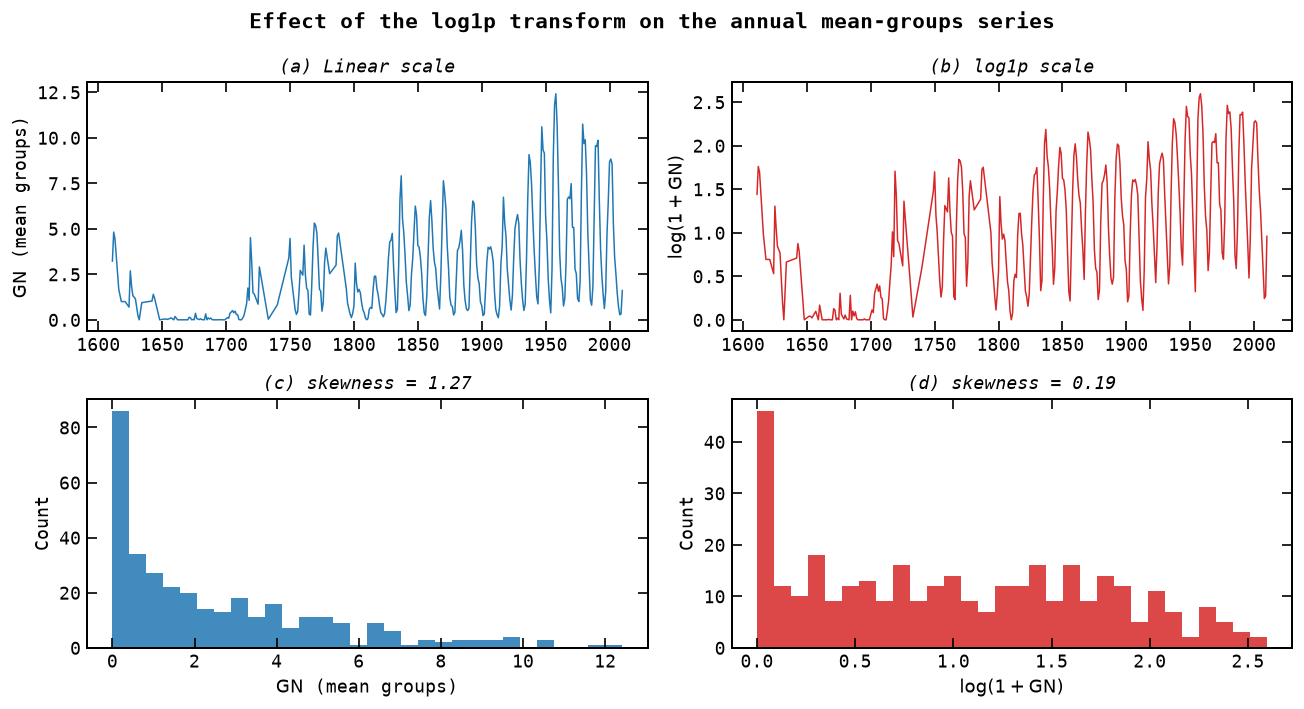

Skewness -- linear: 1.268, log1p: 0.193


In [8]:
_series_ok_tmp = annual_full[annual_full["valid_days"] >= MIN_VALID_DAYS]
_log1p_years = _series_ok_tmp["YEAR"].values
_log1p_mg = _series_ok_tmp["mean_groups"].values
_log1p_log = _series_ok_tmp["log1p_mean_groups"].values
_skew_mg = pd.Series(_log1p_mg).skew()
_skew_log = pd.Series(_log1p_log).skew()

with plt.rc_context(SUPER_MONGO_RC):
    fig, axes = plt.subplots(2, 2, figsize=(11, 6))

    axes[0, 0].plot(_log1p_years, _log1p_mg, color="#1f77b4", linewidth=0.9)
    axes[0, 0].set_ylabel(r"$\mathrm{GN}$ (mean groups)", fontsize=11)
    axes[0, 0].set_title("(a) Linear scale", fontsize=10.5, style="italic")

    axes[0, 1].plot(_log1p_years, _log1p_log, color="#d62728", linewidth=0.9)
    axes[0, 1].set_ylabel(r"$\log(1+\mathrm{GN})$", fontsize=11)
    axes[0, 1].set_title("(b) log1p scale", fontsize=10.5, style="italic")

    axes[1, 0].hist(_log1p_mg, bins=30, color="#1f77b4", alpha=0.85)
    axes[1, 0].set_xlabel(r"$\mathrm{GN}$ (mean groups)", fontsize=11)
    axes[1, 0].set_ylabel("Count", fontsize=11)
    axes[1, 0].set_title(f"(c) skewness = {_skew_mg:.2f}", fontsize=10.5, style="italic")

    axes[1, 1].hist(_log1p_log, bins=30, color="#d62728", alpha=0.85)
    axes[1, 1].set_xlabel(r"$\log(1+\mathrm{GN})$", fontsize=11)
    axes[1, 1].set_ylabel("Count", fontsize=11)
    axes[1, 1].set_title(f"(d) skewness = {_skew_log:.2f}", fontsize=10.5, style="italic")

    for ax in axes.flat:
        ax.tick_params(which="both", direction="in", top=True, right=True)

    fig.suptitle("Effect of the log1p transform on the annual mean-groups series",
                  fontsize=12.5, fontweight="bold")
    plt.tight_layout()
    plt.show()

FIGURES["fig05"] = fig
print(f"Skewness -- linear: {_skew_mg:.3f}, log1p: {_skew_log:.3f}")

Descriptive statistics of the usable years (`valid_days >= 30`), for a
quick sanity check against `annual_series.csv`'s own printed summary:

In [9]:
series_ok = annual_full[annual_full["valid_days"] >= MIN_VALID_DAYS]
display(series_ok[["mean_groups", "active_fraction", "valid_days", "log1p_mean_groups"]].describe())

,mean_groups,active_fraction,valid_days,log1p_mean_groups
count,339.000000,339.000000,339.000000,339.000000
mean,2.570674,0.661873,3102.380531,1.012406
std,2.664696,0.366880,5067.318433,0.723731
min,0.000000,0.000000,30.000000,0.000000
25%,0.405232,0.352941,236.000000,0.340186
50%,1.661290,0.839839,745.000000,0.978811
75%,3.984220,0.988247,3581.000000,1.606277
max,12.416902,1.000000,21957.000000,2.596515


In [10]:
# Collected here; actually written to disk in Section 6 (Export).
EXPORT_TABLES["annual_series"] = annual_full[
    ["YEAR", "mean_groups", "active_fraction", "valid_days", "log1p_mean_groups"]
].copy()
EXPORT_TABLES["coverage"] = annual_full[["YEAR", "valid_days"]].copy()

## Section 2 — Visual inspection of the preprocessed series

This plot uses plain matplotlib defaults, **not** the "Super Mongo" publication
style used from Section 3 onward — it exists only to confirm the series looks
reasonable before any modelling is attempted.

The three panels make one thing visually obvious: **coverage across
1610–2010 is highly uneven**. Large stretches of the 17th and early 18th
century have sparse or missing daily records, which is precisely why the
30-valid-day threshold and the NaN-masking rule in Section 1 exist — without
them, years built from only a handful of observations would be treated as
equally reliable as years built from full seasonal coverage.

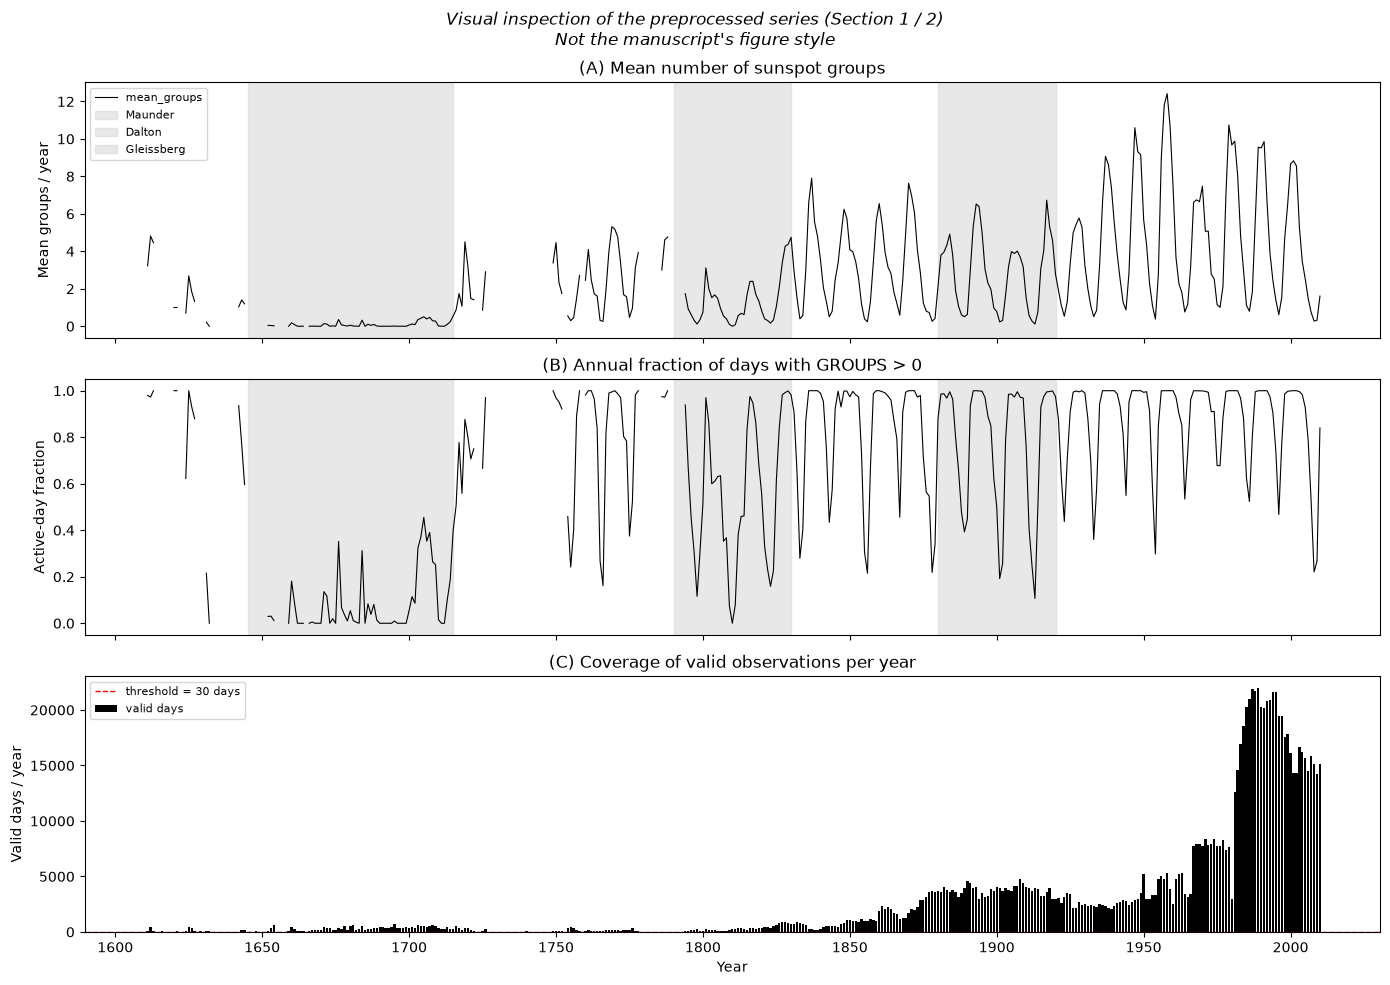

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Visual inspection of the preprocessed series (Section 1 / 2)\n"
             "Not the manuscript's figure style", fontsize=12, style="italic")

ax1, ax2, ax3 = axes
years_all = annual_full["YEAR"].values

ax1.plot(years_all, annual_full["mean_groups"], color="black", linewidth=0.8, label="mean_groups")
ax1.set_ylabel("Mean groups / year")
ax1.set_title("(A) Mean number of sunspot groups")
for name, y1, y2 in [("Maunder", 1645, 1715), ("Dalton", 1790, 1830), ("Gleissberg", 1880, 1920)]:
    ax1.axvspan(y1, y2, color="lightgray", alpha=0.5, label=name)
ax1.legend(fontsize=8, loc="upper left")

ax2.plot(years_all, annual_full["active_fraction"], color="black", linewidth=0.8)
ax2.set_ylabel("Active-day fraction")
ax2.set_title("(B) Annual fraction of days with GROUPS > 0")
for name, y1, y2 in [("Maunder", 1645, 1715), ("Dalton", 1790, 1830), ("Gleissberg", 1880, 1920)]:
    ax2.axvspan(y1, y2, color="lightgray", alpha=0.5)

ax3.bar(years_all, annual_full["valid_days"], color="black", width=0.8, label="valid days")
ax3.axhline(MIN_VALID_DAYS, color="red", linewidth=1.0, linestyle="--",
            label=f"threshold = {MIN_VALID_DAYS} days")
ax3.set_ylabel("Valid days / year")
ax3.set_xlabel("Year")
ax3.set_title("(C) Coverage of valid observations per year")
ax3.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()
FIGURES["inspection_plot"] = fig

## Section 3 — 2-state Hidden Markov Model (proof of concept)



**Method.** A 2-state Gaussian HMM is trained directly on `mean_groups`
(raw scale, not `log1p` — the log transform is introduced only in the
3-state study below). The raw annual mean is right-skewed (skewness 1.27 in Section 1), so the
Gaussian emission model is only a rough approximation on this scale; the
2-state fit is retained here solely as a baseline. Following Rabiner (1989)'s
recommendation for EM-based HMM training, the model is fit from 50 different
random initializations (`random_state = 0, …, 49`) and the restart with the
highest log-likelihood is kept, since Baum–Welch converges only to a local
optimum for any single start. The most likely state sequence is then
recovered via the Viterbi algorithm. Years with `NaN` mean_groups
(insufficient coverage) are excluded from training but kept in the plotted
series.

In [12]:
class _NotConvergingCounter(logging.Handler):
    '''Counts "Model is not converging" log records emitted during ONE fit.'''
    def __init__(self):
        super().__init__()
        self.n = 0

    def emit(self, record):
        if "not converging" in record.getMessage():
            self.n += 1


def fit_hmm_with_restarts(
    X_train: np.ndarray,
    n_states: int,
    n_restarts: int = N_RESTARTS,
    n_iter: int = N_ITER,
    tol: float = TOL,
    covariance_type: str = COVARIANCE_TYPE,
    lengths: np.ndarray | None = None,
    seed0: int = 0,
    hmm_kwargs: dict | None = None,
) -> dict:
    '''Fit a GaussianHMM from `n_restarts` random initializations.

    Returns the model with the highest training log-likelihood, plus
    per-restart bookkeeping: log-likelihood, real EM convergence
    (`monitor_.converged`), whether the EM trace was non-monotone (>=1
    "not converging" warning from hmmlearn), and any fit error. A restart
    that raises during fit/score is recorded (never silently swallowed)
    and never aborts the search.

    `lengths` (optional): passed through to hmmlearn's `fit`/`score` to treat
    `X_train` as several independent sequences (e.g. contiguous blocks of
    valid years) rather than one continuous chain -- see the robustness
    check at the end of Section 4.
    `hmm_kwargs` (optional): extra keyword arguments passed to `GaussianHMM`
    (e.g. `dict(covars_prior=1e-6, min_covar=1e-4)`). With hmmlearn's
    defaults (`covars_prior=1e-2`, `min_covar=1e-3`), the fit is a mildly
    regularised (MAP) estimate, not pure maximum likelihood.
    '''
    lg = logging.getLogger("hmmlearn.base")
    best_model, best_logL, best_seed, hist = None, -np.inf, None, []
    for seed in range(seed0, seed0 + n_restarts):
        model = GaussianHMM(
            n_components=n_states,
            covariance_type=covariance_type,
            n_iter=n_iter,
            tol=tol,
            random_state=seed,
            **(hmm_kwargs or {}),
        )
        counter, old_propagate = _NotConvergingCounter(), lg.propagate
        lg.addHandler(counter)
        lg.propagate = False  # count without also printing to the console
        try:
            model.fit(X_train, lengths=lengths)
            logL = model.score(X_train, lengths=lengths)
            hist.append(dict(seed=seed, logL=logL, converged=bool(model.monitor_.converged),
                              nonmonotone=counter.n > 0, error=None))
            if logL > best_logL:
                best_model, best_logL, best_seed = model, logL, seed
        except Exception as e:
            hist.append(dict(seed=seed, logL=np.nan, converged=False, nonmonotone=False, error=repr(e)))
        finally:
            lg.removeHandler(counter)
            lg.propagate = old_propagate

    ok = [h for h in hist if not np.isnan(h["logL"])]
    assert best_model is not None, f"All {n_restarts} restarts failed (K={n_states}): {hist[0]['error']}"
    ll = np.array([h["logL"] for h in ok])
    return {
        "best_model": best_model,
        "best_seed": best_seed,
        "best_logL": best_logL,
        "logL_history": [(h["seed"], h["logL"]) for h in hist],  # kept for compatibility with the rest of the notebook
        "history": hist,
        "n_failed": len(hist) - len(ok),
        "n_not_converged": int(sum(not h["converged"] for h in ok)),  # reached n_iter without |dlogL| < tol
        "n_nonmonotone": int(sum(h["nonmonotone"] for h in ok)),      # restarts with >=1 "not converging" warning
        "frac_near_best": float(np.mean(ll > best_logL - 0.01)),      # fraction of restarts at the global optimum
        "logL_std": float(ll.std()),
        "logL_range": (float(ll.min()), float(ll.max())),
    }


def get_contiguous_intervals(years: list[int]) -> list[tuple[int, int]]:
    '''Group a list of years into contiguous (start, end) blocks.

    Shared by the 2-state and 3-state sections below (the original scripts
    each defined an identical copy of this helper under a different name).
    '''
    if len(years) == 0:
        return []
    years = sorted(years)
    intervals, y_start, y_prev = [], years[0], years[0]
    for y in years[1:]:
        if y - y_prev > 1:
            intervals.append((y_start, y_prev))
            y_start = y
        y_prev = y
    intervals.append((y_start, y_prev))
    return intervals


In [13]:
df_valid2 = annual_full[annual_full["mean_groups"].notna()].copy()
X_train_2 = df_valid2["mean_groups"].values.reshape(-1, 1)
print(f"Training years : {len(df_valid2)}  ({df_valid2['YEAR'].min()}-{df_valid2['YEAR'].max()})")
print(f"X_train_2 shape: {X_train_2.shape}, min={X_train_2.min():.3f}, "
      f"max={X_train_2.max():.3f}, mean={X_train_2.mean():.3f}")

Training years : 339  (1611-2010)
X_train_2 shape: (339, 1), min=0.000, max=12.417, mean=2.571


In [14]:
result_2state = fit_hmm_with_restarts(X_train_2, n_states=2)
best_seed_2 = result_2state["best_seed"]
best_logL_2 = result_2state["best_logL"]

print(f"Winning seed         : {best_seed_2}")
print(f"Log-likelihood       : {best_logL_2:.6f}")
print(f"LogL range (restarts): {result_2state['logL_range']}")

if best_seed_2 != 24:
    warnings.warn(
        f"Expected winning seed 24 for the 2-state model (as reported in "
        f"hmm2_params.txt), got {best_seed_2}. This can happen with a "
        "different hmmlearn/BLAS build; it does not indicate an error in "
        "this notebook's logic. See the Setup section's version-check note."
    )

Winning seed         : 24
Log-likelihood       : -632.962123
LogL range (restarts): (-812.769882160171, -632.9621228963608)


In [15]:
best_model_2 = result_2state["best_model"]
means_2 = best_model_2.means_.flatten()
stds_2 = np.sqrt(best_model_2.covars_.flatten())
transmat_2 = best_model_2.transmat_
startprob_2 = best_model_2.startprob_

# State B (Grand Minimum) = lower mean; State A (normal) = higher mean.
state_order_2 = np.argsort(means_2)
state_B_idx, state_A_idx = state_order_2[0], state_order_2[1]

print(f"State A (normal)       -- mean={means_2[state_A_idx]:.4f}, std={stds_2[state_A_idx]:.4f}")
print(f"State B (Grand Minimum)-- mean={means_2[state_B_idx]:.4f}, std={stds_2[state_B_idx]:.4f}")
print("Transition matrix (A, B order):")
T2 = transmat_2[np.ix_([state_A_idx, state_B_idx], [state_A_idx, state_B_idx])]
print(T2)

State A (normal)       -- mean=3.3949, std=2.6094
State B (Grand Minimum)-- mean=0.1522, std=0.1760
Transition matrix (A, B order):
[[0.95896492 0.04103508]
 [0.11993379 0.88006621]]


In [16]:
_, state_seq_2 = best_model_2.decode(X_train_2, algorithm="viterbi")
df_valid2["hmm_state"] = state_seq_2
df_valid2["is_grand_minimum"] = (state_seq_2 == state_B_idx).astype(int)

years_B_2state = sorted(df_valid2.loc[df_valid2["is_grand_minimum"] == 1, "YEAR"].tolist())
intervals_B_2state = get_contiguous_intervals(years_B_2state)

if REPRODUCE_PUBLISHED:
    assert len(years_B_2state) == 92, f"Expected 92 years in State B, got {len(years_B_2state)}"

print(f"Total years in State B : {len(years_B_2state)}")
print(f"Contiguous intervals   : {intervals_B_2state}")

Total years in State B : 92
Contiguous intervals   : [(1631, 1632), (1648, 1648), (1652, 1654), (1657, 1657), (1659, 1664), (1666, 1715), (1754, 1756), (1765, 1766), (1797, 1799), (1807, 1812), (1821, 1824), (1855, 1856), (1878, 1879), (1901, 1902), (1911, 1913), (2008, 2009)]


In [17]:
dur_A_2 = 1.0 / T2[0, 1] if T2[0, 1] > 0 else np.inf
dur_B_2 = 1.0 / T2[1, 0] if T2[1, 0] > 0 else np.inf

hmm2_report_lines = [
    "=" * 65,
    "  2-STATE HMM -- MODEL PARAMETERS (proof of concept)",
    "=" * 65,
    "",
    f"Input variable         : mean_groups",
    f"Training period        : {df_valid2['YEAR'].min()}-{df_valid2['YEAR'].max()}",
    f"Training years         : {len(df_valid2)}",
    f"Excluded years (NaN)   : {(annual_full['mean_groups'].isna()).sum()}",
    f"Number of states       : 2",
    f"Covariance type        : {COVARIANCE_TYPE}",
    f"Restarts               : {N_RESTARTS}",
    "",
    f"Winning seed           : {best_seed_2}",
    f"Log-likelihood         : {best_logL_2:.6f}",
    "",
    f"State A (normal)   -- mu={means_2[state_A_idx]:.6f}, sigma={stds_2[state_A_idx]:.6f}",
    f"State B (Gr. Min.) -- mu={means_2[state_B_idx]:.6f}, sigma={stds_2[state_B_idx]:.6f}",
    "",
    "Transition matrix (A, B order):",
    f"  A -> {T2[0,0]:.6f}  {T2[0,1]:.6f}",
    f"  B -> {T2[1,0]:.6f}  {T2[1,1]:.6f}",
    "",
    f"Expected duration -- State A: {dur_A_2:.1f} yr, State B: {dur_B_2:.1f} yr",
    "",
    f"State-B years ({len(years_B_2state)}): {years_B_2state}",
    "Contiguous intervals:",
] + [f"  {y1}-{y2} ({y2-y1+1} yr)" for y1, y2 in intervals_B_2state] + ["=" * 65]

PARAM_REPORTS["hmm2_params"] = "\n".join(hmm2_report_lines)
print(PARAM_REPORTS["hmm2_params"])

  2-STATE HMM -- MODEL PARAMETERS (proof of concept)

Input variable         : mean_groups
Training period        : 1611-2010
Training years         : 339
Excluded years (NaN)   : 62
Number of states       : 2
Covariance type        : full
Restarts               : 50

Winning seed           : 24
Log-likelihood         : -632.962123

State A (normal)   -- mu=3.394892, sigma=2.609440
State B (Gr. Min.) -- mu=0.152157, sigma=0.175957

Transition matrix (A, B order):
  A -> 0.958965  0.041035
  B -> 0.119934  0.880066

Expected duration -- State A: 24.4 yr, State B: 8.3 yr

State-B years (92): [1631, 1632, 1648, 1652, 1653, 1654, 1657, 1659, 1660, 1661, 1662, 1663, 1664, 1666, 1667, 1668, 1669, 1670, 1671, 1672, 1673, 1674, 1675, 1676, 1677, 1678, 1679, 1680, 1681, 1682, 1683, 1684, 1685, 1686, 1687, 1688, 1689, 1690, 1691, 1692, 1693, 1694, 1695, 1696, 1697, 1698, 1699, 1700, 1701, 1702, 1703, 1704, 1705, 1706, 1707, 1708, 1709, 1710, 1711, 1712, 1713, 1714, 1715, 1754, 1755, 1756, 1765, 

### Publication figure (2-state model)

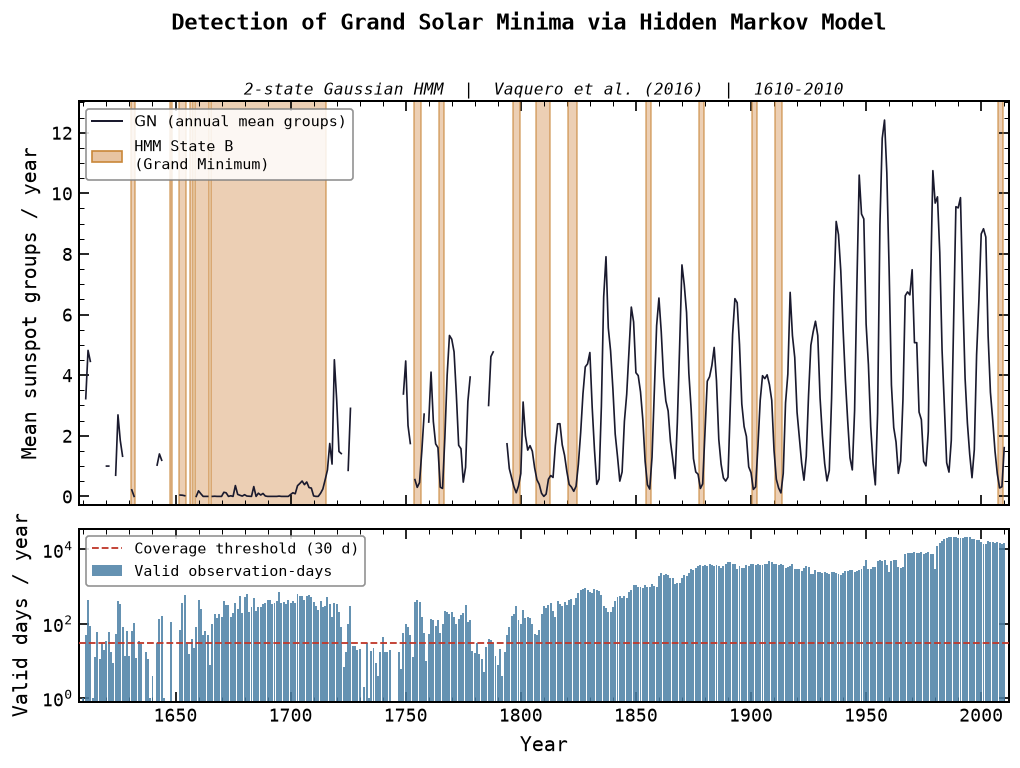

In [18]:
with plt.rc_context(SUPER_MONGO_RC):
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 6.5), sharex=True,
        gridspec_kw={"height_ratios": [2.8, 1.2], "hspace": 0.08},
    )

    years_all = annual_full["YEAR"].values
    mg_all = annual_full["mean_groups"].values
    vd_all = annual_full["valid_days"].values

    for y1, y2 in intervals_B_2state:
        ax1.axvspan(y1 - 0.5, y2 + 0.5, color="#e8c4a2", alpha=0.80, linewidth=0, zorder=1)
        ax1.axvline(y1 - 0.5, color="#c9873a", linewidth=0.9, alpha=0.7, zorder=2)
        ax1.axvline(y2 + 0.5, color="#c9873a", linewidth=0.9, alpha=0.7, zorder=2)

    ax1.plot(years_all, mg_all, color="#1a1a2e", linewidth=1.0, zorder=3)
    ax1.set_ylabel("Mean sunspot groups / year", fontsize=12, labelpad=6)
    ax1.set_ylim(bottom=-0.3)

    patch_shade = mpatches.Patch(facecolor="#e8c4a2", edgecolor="#c9873a",
                                  label="HMM State B\n(Grand Minimum)")
    line_series = plt.Line2D([0], [0], color="#1a1a2e", linewidth=1.2,
                              label=r"$\mathrm{GN}$ (annual mean groups)")
    ax1.legend(handles=[line_series, patch_shade], loc="upper left",
               fontsize=9, framealpha=0.85, edgecolor="gray")
    ax1.xaxis.set_minor_locator(MultipleLocator(10))
    ax1.yaxis.set_minor_locator(AutoMinorLocator(4))

    ax2.bar(years_all, vd_all, width=0.85, color="#4a7fa5", alpha=0.85,
            zorder=2, label="Valid observation-days")
    ax2.axhline(MIN_VALID_DAYS, color="#c0392b", linewidth=1.1, linestyle="--",
                zorder=3, label=f"Coverage threshold ({MIN_VALID_DAYS} d)")
    ax2.set_ylabel("Valid days / year", fontsize=12, labelpad=6)
    ax2.set_xlabel("Year", fontsize=12, labelpad=6)
    ax2.legend(loc="upper left", fontsize=9, framealpha=0.85, edgecolor="gray")
    ax2.set_yscale("log")
    ax2.set_ylim(bottom=0.8)
    ax2.xaxis.set_minor_locator(MultipleLocator(10))

    for ax in (ax1, ax2):
        ax.set_xlim(1608, 2012)
        ax.xaxis.set_major_locator(MultipleLocator(50))
        ax.tick_params(which="both", direction="in", top=True, right=True)

    fig.suptitle("Detection of Grand Solar Minima via Hidden Markov Model",
                  fontsize=13, fontweight="bold", y=0.995)
    ax1.set_title("2-state Gaussian HMM  |  Vaquero et al. (2016)  |  1610-2010",
                   fontsize=9.5, style="italic", pad=4)
    plt.show()

FIGURES["figure_2state"] = fig

## Section 4 — 3-state Hidden Markov Model (full model-selection study)


**Method.** The model now trains on `log1p_mean_groups`. For each candidate
number of states *n* ∈ {2, 3, 4}, the same 50-restart / best-log-likelihood
protocol from Section 3 is repeated (via the shared `fit_hmm_with_restarts`
helper), and the Bayesian Information Criterion is used to compare the
resulting models:

BIC = −2·log L̂ + k·ln(n_train)

with the number of free parameters for an *n*-state full-covariance Gaussian
HMM:

k(n) = n(n−1) + (n−1) + 2n = n² + 2n − 1

(*n*(*n*−1) free transition probabilities, *n*−1 free initial-state
probabilities, and 2*n* emission parameters — one mean and one variance per
state).

In [19]:
df_valid3 = annual_full[annual_full["log1p_mean_groups"].notna()].copy()
X_train_3 = df_valid3["log1p_mean_groups"].values.reshape(-1, 1)
n_train = len(X_train_3)
print(f"Training years : {n_train}  ({df_valid3['YEAR'].min()}-{df_valid3['YEAR'].max()})")
print(f"X_train_3 shape: {X_train_3.shape}, min={X_train_3.min():.4f}, "
      f"max={X_train_3.max():.4f}, mean={X_train_3.mean():.4f}")

Training years : 339  (1611-2010)
X_train_3 shape: (339, 1), min=0.0000, max=2.5965, mean=1.0124


In [20]:
def bic_params(n_states: int) -> int:
    '''Free-parameter count for a full-covariance n-state GaussianHMM.'''
    return n_states * (n_states - 1) + (n_states - 1) + 2 * n_states


def compute_bic(log_L: float, n_params: int, n_train: int) -> float:
    return -2 * log_L + n_params * np.log(n_train)


bic_rows, best_models_3, logL_history_by_n = [], {}, {}
for n_states in (2, 3, 4):
    result = fit_hmm_with_restarts(X_train_3, n_states=n_states)
    k = bic_params(n_states)
    bic = compute_bic(result["best_logL"], k, n_train)
    bic_rows.append({
        "n_states": n_states,
        "log_L": result["best_logL"],
        "n_params": k,
        "BIC": bic,
        "best_seed": result["best_seed"],
        "logL_std": result["logL_std"],
        "n_nonmonotone": result["n_nonmonotone"],        # restarts (out of N_RESTARTS) with a "not converging" warning
        "n_not_converged": result["n_not_converged"],    # restarts that did not converge within N_ITER iterations
        "frac_near_best": result["frac_near_best"],
        "n_failed": result["n_failed"],
    })
    best_models_3[n_states] = result["best_model"]
    logL_history_by_n[n_states] = result["logL_history"]
    print(f"n={n_states}: best_seed={result['best_seed']:2d}, logL={result['best_logL']:.4f}, "
          f"k={k}, BIC={bic:.4f}, non-monotone={result['n_nonmonotone']}/{N_RESTARTS}, "
          f"not-converged={result['n_not_converged']}/{N_RESTARTS}, "
          f"restarts at optimum={100*result['frac_near_best']:.0f}%")

bic_df = pd.DataFrame(bic_rows)
display(bic_df)


n=2: best_seed= 9, logL=-232.4701, k=7, BIC=505.7223, non-monotone=0/50, not-converged=0/50, restarts at optimum=68%


n=3: best_seed= 6, logL=-144.2298, k=14, BIC=370.0237, non-monotone=0/50, not-converged=0/50, restarts at optimum=80%


n=4: best_seed=49, logL=-105.0416, k=23, BIC=344.0813, non-monotone=1/50, not-converged=0/50, restarts at optimum=20%


,n_states,log_L,n_params,BIC,best_seed,logL_std,n_nonmonotone,n_not_converged,frac_near_best,n_failed
0,2,-232.470146,7,505.722292,9,64.577877,0,0,0.68,0
1,3,-144.229828,14,370.023657,6,51.357802,0,0,0.80,0
2,4,-105.041645,23,344.081292,49,54.722189,1,0,0.20,0


### Stability of the 50-restart search across candidate models

Rather than only reporting the best log-likelihood found per model, the
boxplot below shows the full distribution of log-likelihoods across all 50
random restarts, for each candidate number of states. A tight, high
distribution indicates the search converges reliably to essentially the
same optimum regardless of initialization; a wide or multi-modal
distribution indicates instability -- directly relevant to the $K=4$
convergence-warning issue discussed above.

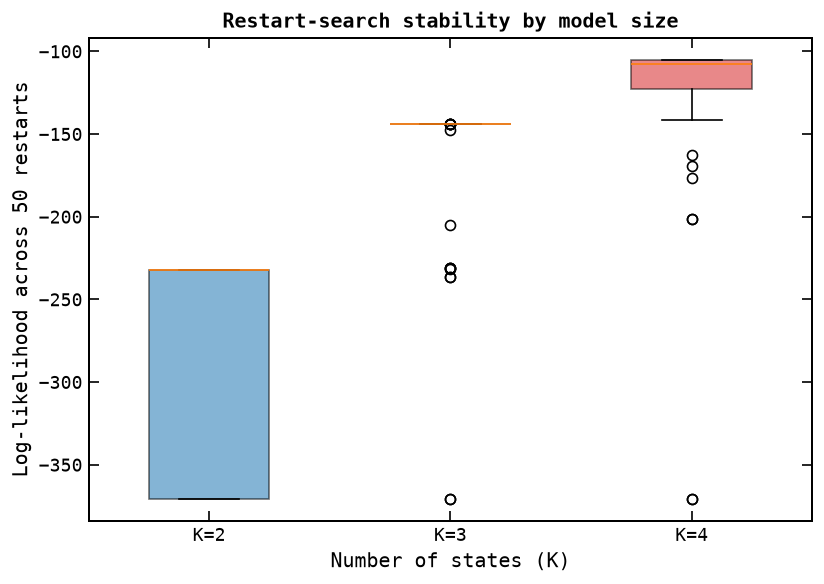

K=2: n_restarts_completed_without_error=50/50, logL range=[-370.91, -232.47], std=64.578
K=3: n_restarts_completed_without_error=50/50, logL range=[-370.91, -144.23], std=51.358
K=4: n_restarts_completed_without_error=50/50, logL range=[-370.91, -105.04], std=54.722


In [21]:
_logL_box_data = [
    [ll for _, ll in logL_history_by_n[n] if not np.isnan(ll)]
    for n in (2, 3, 4)
]

with plt.rc_context(SUPER_MONGO_RC):
    fig, ax = plt.subplots(figsize=(7, 5))
    bp = ax.boxplot(_logL_box_data, tick_labels=["K=2", "K=3", "K=4"],
                     patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], ["#1f77b4", "#2ca02c", "#d62728"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)
    ax.set_ylabel("Log-likelihood across 50 restarts", fontsize=12)
    ax.set_xlabel("Number of states (K)", fontsize=12)
    ax.set_title("Restart-search stability by model size", fontsize=12, fontweight="bold")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    plt.tight_layout()
    plt.show()

FIGURES["restart_stability"] = fig
for n, vals in zip((2, 3, 4), _logL_box_data):
    print(f"K={n}: n_restarts_completed_without_error={len(vals)}/{N_RESTARTS}, "
          f"logL range=[{min(vals):.2f}, {max(vals):.2f}], std={np.std(vals):.3f}")

In [22]:
_expected_bic = np.array([505.722292, 370.023657, 344.081292])
if not np.allclose(bic_df["BIC"].values, _expected_bic, rtol=1e-4):
    warnings.warn(
        f"Computed BIC values {bic_df['BIC'].values} differ from the "
        f"published values {_expected_bic} by more than the expected "
        "floating-point tolerance. Re-check the toolchain versions above."
    )
else:
    print("BIC values match the published bic_table.csv within tolerance.")

RAW_BIC_ARGMIN = int(bic_df.loc[bic_df["BIC"].idxmin(), "n_states"])
print(f"Raw BIC minimum is at n_states = {RAW_BIC_ARGMIN}")

BIC values match the published bic_table.csv within tolerance.
Raw BIC minimum is at n_states = 4


### Model-selection summary figure

The panel below consolidates, in one view, the four quantities used above
to justify selecting $K=3$ over the raw BIC optimum $K=4$: the BIC itself,
the log-likelihood, the number of the 50 restarts that triggered an
hmmlearn "not converging" warning, and the shortest expected state sojourn
time in the fitted model (in years). $K=4$'s implausibly short minimum
sojourn time and elevated convergence-warning count are the quantitative
basis for preferring $K=3$ despite its higher BIC.

,n_states,log_L,n_params,BIC,best_seed,logL_std,n_nonmonotone,n_not_converged,frac_near_best,n_failed,min_sojourn_yr
0,2,-232.470146,7,505.722292,9,64.577877,0,0,0.68,0,18.909970
1,3,-144.229828,14,370.023657,6,51.357802,0,0,0.80,0,5.160326
2,4,-105.041645,23,344.081292,49,54.722189,1,0,0.20,0,2.034115


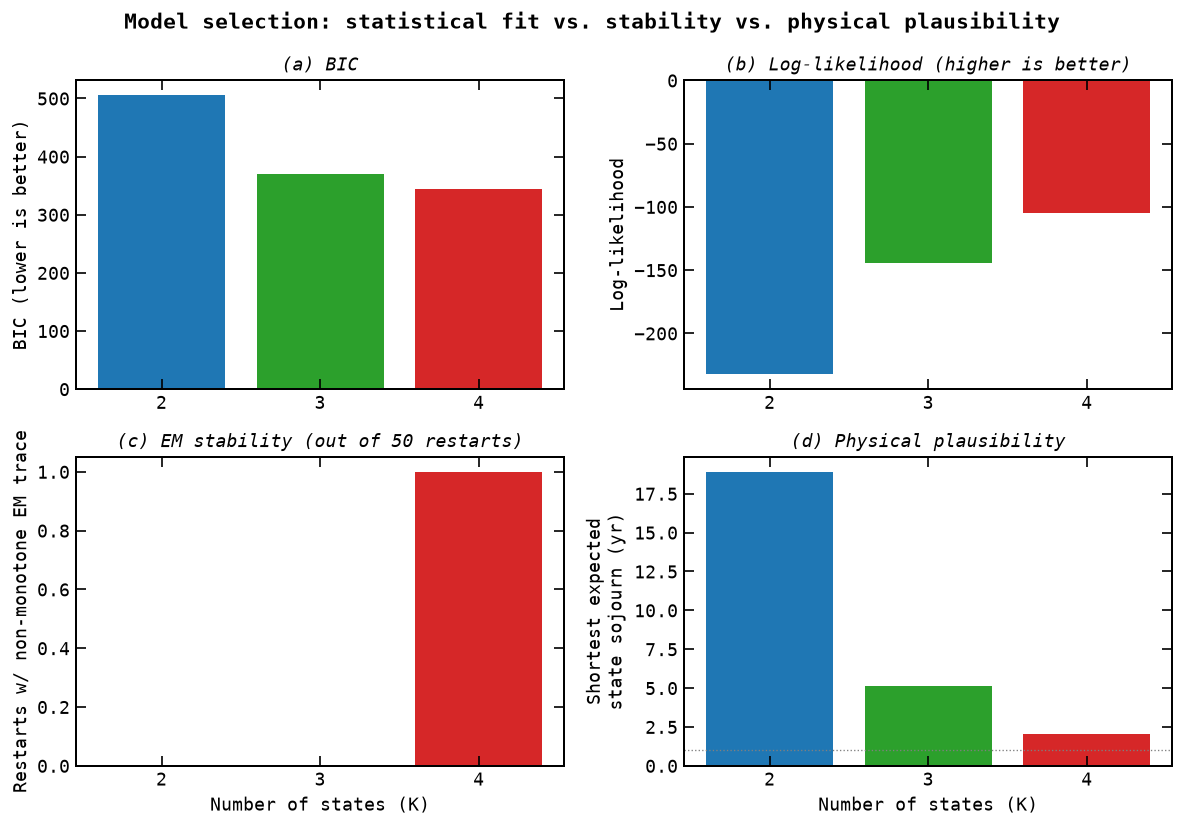

In [23]:
_min_sojourn_by_n = {}
for n_states, model in best_models_3.items():
    T = model.transmat_
    sojourns = [1.0 / (1.0 - T[i, i]) if T[i, i] < 1 else np.inf for i in range(n_states)]
    _min_sojourn_by_n[n_states] = min(sojourns)

_summary_df = bic_df.copy()
_summary_df["min_sojourn_yr"] = _summary_df["n_states"].map(_min_sojourn_by_n)
display(_summary_df)

with plt.rc_context(SUPER_MONGO_RC):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    _x = _summary_df["n_states"].astype(str).values
    _colors = ["#1f77b4", "#2ca02c", "#d62728"]

    axes[0, 0].bar(_x, _summary_df["BIC"], color=_colors)
    axes[0, 0].set_ylabel("BIC (lower is better)", fontsize=11)
    axes[0, 0].set_title("(a) BIC", fontsize=10.5, style="italic")

    axes[0, 1].bar(_x, _summary_df["log_L"], color=_colors)
    axes[0, 1].set_ylabel("Log-likelihood", fontsize=11)
    axes[0, 1].set_title("(b) Log-likelihood (higher is better)", fontsize=10.5, style="italic")

    axes[1, 0].bar(_x, _summary_df["n_nonmonotone"], color=_colors)
    axes[1, 0].set_ylabel("Restarts w/ non-monotone EM trace", fontsize=10.5)
    axes[1, 0].set_xlabel("Number of states (K)", fontsize=11)
    axes[1, 0].set_title("(c) EM stability (out of 50 restarts)", fontsize=10.5, style="italic")

    axes[1, 1].bar(_x, _summary_df["min_sojourn_yr"], color=_colors)
    axes[1, 1].axhline(1.0, color="gray", linewidth=0.8, linestyle=":")
    axes[1, 1].set_ylabel("Shortest expected\nstate sojourn (yr)", fontsize=10.5)
    axes[1, 1].set_xlabel("Number of states (K)", fontsize=11)
    axes[1, 1].set_title("(d) Physical plausibility", fontsize=10.5, style="italic")

    for ax in axes.flat:
        ax.tick_params(which="both", direction="in", top=True, right=True)

    fig.suptitle("Model selection: statistical fit vs. stability vs. physical plausibility",
                  fontsize=12.5, fontweight="bold")
    plt.tight_layout()
    plt.show()

FIGURES["model_selection_summary"] = fig

### Why 3 states are selected instead of the raw BIC optimum

The raw BIC minimum falls at *n* = 4 (ΔBIC(3→4) ≈ 26, nominally a strong
preference). Nevertheless, **this analysis deliberately selects *n* = 3**,
for three concrete reasons observed in the 4-state fit:

1. It shows convergence warnings from `hmmlearn`'s EM optimizer, indicating
   an unstable fit rather than a well-identified additional regime.
2. It produces a state with an expected sojourn time of only ~2 years —
   physically incoherent with the ~11-year Schwabe solar cycle that any
   "normal activity" state should represent.
3. The extra component fragments the variability of the normal cycle
   without an obvious correspondence to a recognised solar-activity regime;
   we have not tested this correspondence formally.

The 3-state model, in contrast, is physically interpretable (Grand Minimum /
Reduced Activity / Normal Activity) and converges stably. This is a
documented, deliberate departure from the raw statistical optimum — carried
over unchanged from the original analysis — not an error to reconcile with
the BIC table above; the ΔBIC is reported precisely so the trade-off stays
visible to the reader.

In [24]:
SELECTED_N_STATES = 3  # deliberate override -- see markdown above
print(f"Raw BIC minimum        : n_states = {RAW_BIC_ARGMIN}")
print(f"Selected for this study: n_states = {SELECTED_N_STATES}  "
      "(physical interpretability + convergence stability)")

Raw BIC minimum        : n_states = 4
Selected for this study: n_states = 3  (physical interpretability + convergence stability)


In [25]:
best_model_3 = best_models_3[SELECTED_N_STATES]
best_logL_3 = bic_df.loc[bic_df["n_states"] == SELECTED_N_STATES, "log_L"].values[0]
best_seed_3 = int(bic_df.loc[bic_df["n_states"] == SELECTED_N_STATES, "best_seed"].values[0])

if best_seed_3 != 6:
    warnings.warn(
        f"Expected winning seed 6 for the selected 3-state model, got "
        f"{best_seed_3}. This can happen with a different hmmlearn/BLAS "
        "build and does not by itself indicate an error."
    )

means_3 = best_model_3.means_.flatten()
stds_3 = np.sqrt(best_model_3.covars_.flatten())
transmat_3 = best_model_3.transmat_
startprob_3 = best_model_3.startprob_

# Ascending mean -> C (Grand Minimum), B (Reduced Activity), A (Normal Activity)
state_order_3 = np.argsort(means_3)
state_C_idx, state_B_idx3, state_A_idx3 = state_order_3

print(f"Winning seed : {best_seed_3}")
print(f"Log-lik.     : {best_logL_3:.6f}")
print(f"State A (Normal)    -- mean_log1p={means_3[state_A_idx3]:.4f}, std={stds_3[state_A_idx3]:.4f}")
print(f"State B (Reduced)   -- mean_log1p={means_3[state_B_idx3]:.4f}, std={stds_3[state_B_idx3]:.4f}")
print(f"State C (Grand Min) -- mean_log1p={means_3[state_C_idx]:.4f}, std={stds_3[state_C_idx]:.4f}")

Winning seed : 6
Log-lik.     : -144.229828
State A (Normal)    -- mean_log1p=1.7438, std=0.3646
State B (Reduced)   -- mean_log1p=0.6778, std=0.3388
State C (Grand Min) -- mean_log1p=0.0318, std=0.0457


In [26]:
def inv_log1p(y):
    '''Inverse of log1p: exp(y) - 1.'''
    return np.expm1(y)

mu_A = inv_log1p(means_3[state_A_idx3])
mu_B = inv_log1p(means_3[state_B_idx3])
mu_C = inv_log1p(means_3[state_C_idx])

print("Emission means in the original mean_groups scale:")
print(f"  State A: ~{mu_A:.3f} groups/day")
print(f"  State B: ~{mu_B:.3f} groups/day")
print(f"  State C: ~{mu_C:.3f} groups/day")

order_ABC = [state_A_idx3, state_B_idx3, state_C_idx]
T3 = transmat_3[np.ix_(order_ABC, order_ABC)]  # reordered A, B, C
print("\nTransition matrix (A, B, C order):")
print(T3)

Emission means in the original mean_groups scale:
  State A: ~4.719 groups/day
  State B: ~0.970 groups/day
  State C: ~0.032 groups/day

Transition matrix (A, B, C order):
[[8.27849247e-01 1.72150753e-01 1.44304140e-24]
 [1.56223806e-01 8.06213779e-01 3.75624151e-02]
 [2.44792555e-95 1.03676462e-01 8.96323538e-01]]


In [27]:
def shannon_entropy(row: np.ndarray) -> float:
    '''Shannon entropy (bits) of one row of a transition matrix.'''
    row = np.asarray(row)
    row = row[row > 0]  # avoid log(0)
    return float(-np.sum(row * np.log2(row)))

H_A = shannon_entropy(transmat_3[state_A_idx3])
H_B = shannon_entropy(transmat_3[state_B_idx3])
H_C = shannon_entropy(transmat_3[state_C_idx])

dur_A = 1.0 / (1.0 - T3[0, 0])
dur_B = 1.0 / (1.0 - T3[1, 1])
dur_C = 1.0 / (1.0 - T3[2, 2])

print(f"Shannon entropy (bits) -- H(A)={H_A:.4f}, H(B)={H_B:.4f}, H(C)={H_C:.4f}")
print(f"Expected duration (yr) -- A={dur_A:.1f}, B={dur_B:.1f}, C={dur_C:.1f}")

Shannon entropy (bits) -- H(A)=0.6626, H(B)=0.8468, H(C)=0.4805
Expected duration (yr) -- A=5.8, B=5.2, C=9.6


In [28]:
_checks = {
    "mu_A (log1p)": (means_3[state_A_idx3], 1.743773),
    "mu_B (log1p)": (means_3[state_B_idx3], 0.677781),
    "mu_C (log1p)": (means_3[state_C_idx], 0.031798),
    "H_A": (H_A, 0.6626), "H_B": (H_B, 0.8468), "H_C": (H_C, 0.4805),
    "dur_A": (dur_A, 5.8), "dur_B": (dur_B, 5.2), "dur_C": (dur_C, 9.6),
}
for name, (got, expected) in _checks.items():
    if not np.isclose(got, expected, atol=1e-2):
        warnings.warn(f"{name}: computed {got:.4f} vs. published {expected:.4f}")
print("Parameter cross-check against hmm3_params.txt complete "
      "(see warnings above for any mismatch beyond floating-point tolerance).")

Parameter cross-check against hmm3_params.txt complete (see warnings above for any mismatch beyond floating-point tolerance).


/var/folders/1m/whc0_ck14x37_09_jw61tblc0000gn/T/ipykernel_36654/2758287784.py:10: UserWarning: dur_B: computed 5.1603 vs. published 5.2000
  warnings.warn(f"{name}: computed {got:.4f} vs. published {expected:.4f}")
/var/folders/1m/whc0_ck14x37_09_jw61tblc0000gn/T/ipykernel_36654/2758287784.py:10: UserWarning: dur_C: computed 9.6454 vs. published 9.6000
  warnings.warn(f"{name}: computed {got:.4f} vs. published {expected:.4f}")


In [29]:
_, state_seq_3 = best_model_3.decode(X_train_3, algorithm="viterbi")
idx_to_label = {state_A_idx3: "A", state_B_idx3: "B", state_C_idx: "C"}
state_label_seq = np.array([idx_to_label[s] for s in state_seq_3])

df_valid3["hmm_state_label"] = state_label_seq
df_valid3["is_grand_minimum"] = (state_label_seq == "C").astype(int)

years_C = sorted(df_valid3.loc[df_valid3["hmm_state_label"] == "C", "YEAR"].tolist())
years_B = sorted(df_valid3.loc[df_valid3["hmm_state_label"] == "B", "YEAR"].tolist())
intervals_C = get_contiguous_intervals(years_C)
intervals_B = get_contiguous_intervals(years_B)

_expected_intervals_C = [(1648, 1648), (1652, 1654), (1657, 1657), (1659, 1664),
                          (1666, 1675), (1677, 1683), (1685, 1702), (1710, 1713),
                          (1809, 1811)]
if REPRODUCE_PUBLISHED:
    assert len(years_C) == 53, f"Expected 53 years in State C, got {len(years_C)}"
    assert intervals_C == _expected_intervals_C, (
        f"State-C intervals differ from the published list:\n"
        f"  computed: {intervals_C}\n  expected: {_expected_intervals_C}"
    )

print(f"State C (Grand Minimum): {len(years_C)} years, {len(intervals_C)} contiguous intervals")
print(f"State B (Reduced Activity): {len(years_B)} years, {len(intervals_B)} contiguous intervals")

State C (Grand Minimum): 53 years, 9 contiguous intervals
State B (Reduced Activity): 147 years, 39 contiguous intervals


### fig06 -- Goodness of fit: emission distributions vs. the observed histogram

A standard check for a Gaussian HMM is whether its fitted per-state normal
densities, combined according to each state's empirical share of the
training years, actually resemble the observed marginal distribution of the
training variable. The histogram below overlays the three fitted
$\mathcal{N}(\mu_k, \sigma_k^2)$ densities (weighted by each state's share
of the 339 training years) and their sum against the histogram of
`log1p_mean_groups`.

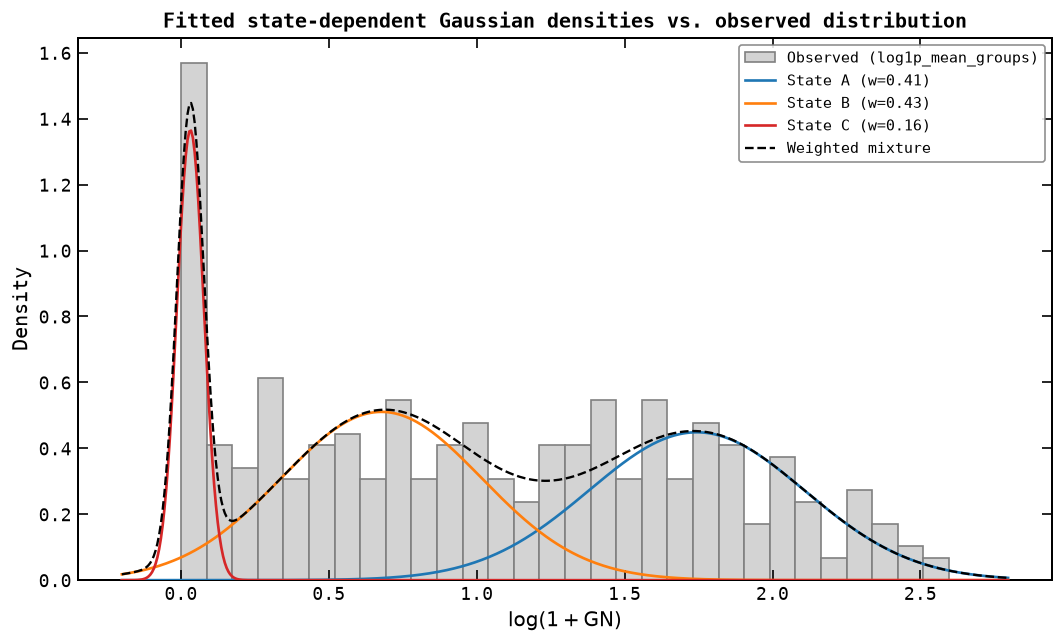

In [30]:
_state_weights = {
    "A": np.mean(state_label_seq == "A"),
    "B": np.mean(state_label_seq == "B"),
    "C": np.mean(state_label_seq == "C"),
}
_state_params = {
    "A": (means_3[state_A_idx3], stds_3[state_A_idx3]),
    "B": (means_3[state_B_idx3], stds_3[state_B_idx3]),
    "C": (means_3[state_C_idx], stds_3[state_C_idx]),
}

_x_grid = np.linspace(X_train_3.min() - 0.2, X_train_3.max() + 0.2, 500)

def _gaussian_pdf(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

with plt.rc_context(SUPER_MONGO_RC):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.hist(X_train_3.flatten(), bins=30, density=True, color="lightgray",
            edgecolor="gray", label="Observed (log1p_mean_groups)", zorder=1)

    _mixture = np.zeros_like(_x_grid)
    for lbl, color in zip(("A", "B", "C"), ("#1f77b4", "#ff7f0e", "#d62728")):
        mu, sigma = _state_params[lbl]
        w = _state_weights[lbl]
        density = w * _gaussian_pdf(_x_grid, mu, sigma)
        _mixture += density
        ax.plot(_x_grid, density, color=color, linewidth=1.6,
                 label=f"State {lbl} (w={w:.2f})", zorder=3)

    ax.plot(_x_grid, _mixture, color="black", linewidth=1.4, linestyle="--",
             label="Weighted mixture", zorder=4)

    ax.set_xlabel(r"$\log(1+\mathrm{GN})$", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title("Fitted state-dependent Gaussian densities vs. observed distribution",
                  fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, framealpha=0.88, edgecolor="gray")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    plt.tight_layout()
    plt.show()

FIGURES["fig06"] = fig

### Diagnostic: within-state independence of emissions

A discrete-state HMM assumes emissions within a state are conditionally
i.i.d. given the state. \citet{Zimmerman2024} point out that this can be
violated in practice if there is a residual trend or dependence within a
state's observations. As a simple check, we compute each year's residual
from its assigned state's fitted mean, then estimate the lag-1
autocorrelation of these residuals *restricted to pairs of consecutive
calendar years both assigned to the same state* (non-consecutive or
cross-state pairs are excluded, since the model makes no i.i.d. claim about
them).

In [31]:
_state_means_lookup = {"A": means_3[state_A_idx3], "B": means_3[state_B_idx3], "C": means_3[state_C_idx]}
_resid_df = pd.DataFrame({
    "YEAR": df_valid3["YEAR"].values,
    "value": X_train_3.flatten(),
    "label": state_label_seq,
})
_resid_df["residual"] = _resid_df["value"] - _resid_df["label"].map(_state_means_lookup)

print("Lag-1 autocorrelation of residuals within each state")
print("(consecutive calendar years both assigned to the same state only):")
for lbl in ("A", "B", "C"):
    _sub = _resid_df[_resid_df["label"] == lbl].set_index("YEAR")["residual"]
    _pairs = [(_sub[y], _sub[y + 1]) for y in _sub.index if (y + 1) in _sub.index]
    if len(_pairs) >= 3:
        _arr = np.array(_pairs)
        _corr = np.corrcoef(_arr[:, 0], _arr[:, 1])[0, 1]
        print(f"  State {lbl}: n_consecutive_pairs={len(_pairs):3d}, lag-1 autocorrelation = {_corr:+.3f}")
    else:
        print(f"  State {lbl}: only {len(_pairs)} consecutive-year pairs -- too few to estimate reliably")

Lag-1 autocorrelation of residuals within each state
(consecutive calendar years both assigned to the same state only):
  State A: n_consecutive_pairs=113, lag-1 autocorrelation = +0.607
  State B: n_consecutive_pairs=108, lag-1 autocorrelation = +0.439
  State C: n_consecutive_pairs= 44, lag-1 autocorrelation = +0.224


### Diagnostic: sensitivity to pre-1750 non-stationarity

The Limitations discussion notes that the observational network grew from a
single observer in the early seventeenth century to dozens of stations in
the modern era, introducing heterogeneity unrelated to solar physics. As a
direct check, we refit the model using only years from 1750 onwards (the
era of denser, more homogeneous coverage), with the same 50-restart
protocol for $K=2,3,4$, and compare the resulting state structure against
the primary 1610-2010 analysis.

In [32]:
_mask_1750 = annual_full["YEAR"] >= 1750
_df_1750 = annual_full[_mask_1750 & annual_full["log1p_mean_groups"].notna()].copy()
X_1750 = _df_1750["log1p_mean_groups"].values.reshape(-1, 1)
n_1750 = len(X_1750)
print(f"Training years (>=1750): {n_1750}  (vs. {n_train} in the primary 1610-2010 analysis)")

_bic_1750_rows, _models_1750 = [], {}
for n_states in (2, 3, 4):
    result = fit_hmm_with_restarts(X_1750, n_states=n_states)
    k = bic_params(n_states)
    bic = compute_bic(result["best_logL"], k, n_1750)
    _bic_1750_rows.append({"n_states": n_states, "log_L": result["best_logL"],
                            "n_params": k, "BIC": bic, "best_seed": result["best_seed"]})
    _models_1750[n_states] = result["best_model"]
    print(f"n={n_states}: best_seed={result['best_seed']:2d}, logL={result['best_logL']:.4f}, "
          f"k={k}, BIC={bic:.4f}")

bic_1750_df = pd.DataFrame(_bic_1750_rows)
display(bic_1750_df)

Training years (>=1750): 248  (vs. 339 in the primary 1610-2010 analysis)


n=2: best_seed=10, logL=-177.7042, k=7, BIC=394.0024


n=3: best_seed=26, logL=-142.0357, k=14, BIC=361.2594


n=4: best_seed=24, logL=-105.3249, k=23, BIC=337.4586


,n_states,log_L,n_params,BIC,best_seed
0,2,-177.704221,7,394.002444,10
1,3,-142.035695,14,361.259393,26
2,4,-105.324869,23,337.458600,24


In [33]:
_m3_1750 = _models_1750[3]
_means_1750 = _m3_1750.means_.flatten()
_stds_1750 = np.sqrt(_m3_1750.covars_.flatten())
_order_1750 = np.argsort(_means_1750)
_T_1750 = _m3_1750.transmat_

print("Post-1750-only 3-state model, states ordered by ascending mean (log1p scale):")
for rank, idx in enumerate(_order_1750):
    dur = 1.0 / (1.0 - _T_1750[idx, idx]) if _T_1750[idx, idx] < 1 else np.inf
    print(f"  rank {rank}: mean={_means_1750[idx]:.4f} (~{np.expm1(_means_1750[idx]):.3f} groups/day), "
          f"std={_stds_1750[idx]:.4f}, duration={dur:.2f} yr")

print(f"\nFor comparison, the primary (1610-2010) model's State C: "
      f"mean={means_3[state_C_idx]:.4f} (~{mu_C:.3f} groups/day), duration={dur_C:.2f} yr")
print(f"Primary State B: mean={means_3[state_B_idx3]:.4f} (~{mu_B:.3f} groups/day), duration={dur_B:.2f} yr")

_low = _order_1750[0]
_mu_low = np.expm1(_means_1750[_low])
_dur_low = 1.0 / (1.0 - _T_1750[_low, _low]) if _T_1750[_low, _low] < 1 else np.inf
_closer_to_B = abs(_mu_low - mu_B) < abs(_mu_low - mu_C)
print(f"\nLowest state (>=1750 only): ~{_mu_low:.3f} groups/day, duration {_dur_low:.1f} yr | "
      f"primary State C: ~{mu_C:.3f} groups/day, {dur_C:.1f} yr | "
      f"primary State B: ~{mu_B:.3f} groups/day, {dur_B:.1f} yr")
print("-> closer to State B than to State C." if _closer_to_B
      else "-> closer to State C than to State B.")

Post-1750-only 3-state model, states ordered by ascending mean (log1p scale):
  rank 0: mean=0.5593 (~0.749 groups/day), std=0.2722, duration=3.97 yr
  rank 1: mean=1.2789 (~2.593 groups/day), std=0.1953, duration=1.48 yr
  rank 2: mean=1.9294 (~5.885 groups/day), std=0.2868, duration=4.24 yr

For comparison, the primary (1610-2010) model's State C: mean=0.0318 (~0.032 groups/day), duration=9.65 yr
Primary State B: mean=0.6778 (~0.970 groups/day), duration=5.16 yr

Lowest state (>=1750 only): ~0.749 groups/day, duration 4.0 yr | primary State C: ~0.032 groups/day, 9.6 yr | primary State B: ~0.970 groups/day, 5.2 yr
-> closer to State B than to State C.


### Independent validation via `active_fraction`

`active_fraction` was not used to train the model (only `log1p_mean_groups`
was), so agreement between the state assignment and `active_fraction`
provides an independent check that the states are physically meaningful.

In [34]:
active_fraction_stats = {}
for lbl in ("A", "B", "C"):
    subset = df_valid3[df_valid3["hmm_state_label"] == lbl]
    active_fraction_stats[lbl] = {
        "n": len(subset),
        "af_mean": subset["active_fraction"].mean(),
        "af_std": subset["active_fraction"].std(),   # pandas default ddof=1
        "mg_mean": subset["mean_groups"].mean(),
    }
    s = active_fraction_stats[lbl]
    print(f"State {lbl}: n={s['n']:3d}, active_fraction={s['af_mean']:.3f} +/- "
          f"{s['af_std']:.3f}, mean_groups={s['mg_mean']:.3f}")

State A: n=139, active_fraction=0.978 +/- 0.035, mean_groups=5.152
State B: n=147, active_fraction=0.590 +/- 0.255, mean_groups=1.045
State C: n= 53, active_fraction=0.031 +/- 0.045, mean_groups=0.034


In [35]:
results_q2 = annual_full.merge(
    df_valid3[["YEAR", "hmm_state_label", "is_grand_minimum"]],
    on="YEAR", how="left",
)
EXPORT_TABLES["results_q2"] = results_q2[
    ["YEAR", "mean_groups", "active_fraction", "valid_days",
     "log1p_mean_groups", "hmm_state_label", "is_grand_minimum"]
].copy()
EXPORT_TABLES["bic_table"] = bic_df[["n_states", "log_L", "n_params", "BIC"]].copy()

In [36]:
hmm3_report_lines = [
    "=" * 70,
    "  3-STATE HMM -- MODEL PARAMETERS",
    "=" * 70,
    "",
    "Input variable       : log1p_mean_groups = log(1 + mean_groups)",
    f"Training period      : {df_valid3['YEAR'].min()}-{df_valid3['YEAR'].max()}",
    f"Training years       : {n_train}",
    f"Excluded years (NaN) : {(annual_full['log1p_mean_groups'].isna()).sum()}",
    f"Restarts per model   : {N_RESTARTS}",
    f"hmmlearn version      : {_im.version('hmmlearn')}",
    "",
    "BIC model selection (n_states = 2, 3, 4):",
] + [
    f"  n={int(r.n_states)}  log_L={r.log_L:10.4f}  k={int(r.n_params):3d}  "
    f"BIC={r.BIC:10.4f}" + ("  <- SELECTED" if r.n_states == SELECTED_N_STATES else "")
    for r in bic_df.itertuples()
] + [
    "",
    f"Raw BIC optimum is n={RAW_BIC_ARGMIN}; n={SELECTED_N_STATES} is selected instead "
    "on physical/convergence grounds (see markdown discussion above).",
    "",
    f"Winning seed (n={SELECTED_N_STATES}) : {best_seed_3}",
    f"Log-likelihood            : {best_logL_3:.6f}",
    "",
    "Emission parameters (log1p scale / original scale):",
    f"  State A (Normal)    : mu={means_3[state_A_idx3]:.6f}, sigma={stds_3[state_A_idx3]:.6f}  (~{mu_A:.3f} groups/day)",
    f"  State B (Reduced)   : mu={means_3[state_B_idx3]:.6f}, sigma={stds_3[state_B_idx3]:.6f}  (~{mu_B:.3f} groups/day)",
    f"  State C (Grand Min): mu={means_3[state_C_idx]:.6f}, sigma={stds_3[state_C_idx]:.6f}  (~{mu_C:.3f} groups/day)",
    "",
    "Transition matrix (A, B, C order):",
    f"  A -> {T3[0,0]:.6f}  {T3[0,1]:.6f}  {T3[0,2]:.6f}",
    f"  B -> {T3[1,0]:.6f}  {T3[1,1]:.6f}  {T3[1,2]:.6f}",
    f"  C -> {T3[2,0]:.6f}  {T3[2,1]:.6f}  {T3[2,2]:.6f}",
    "",
    f"Expected duration (yr): A={dur_A:.1f}, B={dur_B:.1f}, C={dur_C:.1f}",
    f"Shannon entropy (bits): H(A)={H_A:.4f}, H(B)={H_B:.4f}, H(C)={H_C:.4f}",
    "",
    "Active-fraction validation (not used in training):",
] + [
    f"  State {lbl}: n={s['n']:3d}, active_fraction={s['af_mean']:.3f} +/- {s['af_std']:.3f}, "
    f"mean_groups={s['mg_mean']:.3f}"
    for lbl, s in active_fraction_stats.items()
] + [
    "",
    f"State-C years ({len(years_C)}): {years_C}",
    "State-C contiguous intervals:",
] + [f"  {y1}-{y2} ({y2-y1+1} yr)" for y1, y2 in intervals_C] + [
    "",
    f"State-B years ({len(years_B)}), contiguous intervals:",
] + [f"  {y1}-{y2} ({y2-y1+1} yr)" for y1, y2 in intervals_B] + ["=" * 70]

PARAM_REPORTS["hmm3_params"] = "\n".join(hmm3_report_lines)
print(PARAM_REPORTS["hmm3_params"])

  3-STATE HMM -- MODEL PARAMETERS

Input variable       : log1p_mean_groups = log(1 + mean_groups)
Training period      : 1611-2010
Training years       : 339
Excluded years (NaN) : 62
Restarts per model   : 50
hmmlearn version      : 0.3.3

BIC model selection (n_states = 2, 3, 4):
  n=2  log_L= -232.4701  k=  7  BIC=  505.7223
  n=3  log_L= -144.2298  k= 14  BIC=  370.0237  <- SELECTED
  n=4  log_L= -105.0416  k= 23  BIC=  344.0813

Raw BIC optimum is n=4; n=3 is selected instead on physical/convergence grounds (see markdown discussion above).

Winning seed (n=3) : 6
Log-likelihood            : -144.229828

Emission parameters (log1p scale / original scale):
  State A (Normal)    : mu=1.743773, sigma=0.364557  (~4.719 groups/day)
  State B (Reduced)   : mu=0.677781, sigma=0.338759  (~0.970 groups/day)
  State C (Grand Min): mu=0.031798, sigma=0.045668  (~0.032 groups/day)

Transition matrix (A, B, C order):
  A -> 0.827849  0.172151  0.000000
  B -> 0.156224  0.806214  0.037562
  C -

### Robustness check — sensitivity to the coverage-gap treatment

The 339 training years above are not one unbroken run: they fall into 23
separate contiguous blocks, split by the 62 excluded (`NaN`) years. Simply
concatenating all valid years into a single sequence -- as done above, and
as the original scripts did -- implicitly treats two valid years separated
by a coverage gap as if they were one calendar year apart. Mews et al.
(2025, *Statistical Modelling*, p. 493) note that a discrete-time Markov
model's transition matrix is calibrated to a fixed interval length between
observations, and recommend not letting irregular gaps silently distort
that calibration.

The check below refits the same n=2, 3, 4 models, but passes each
contiguous block as its own sequence to `hmmlearn` (via its `lengths=`
argument), so no transition is assumed *across* a gap. This does not change
which years are excluded -- it only changes what the model assumes about
the (missing) years in between. The comparison below is a sensitivity
check, not a replacement of the primary analysis above: the numbers already
reported (and cross-checked against the manuscript) stand as the paper's
main result.

In [37]:
# Build one "length" per contiguous block of training years, in order,
# so hmmlearn treats each block as an independent sequence.
_years3_sorted = df_valid3["YEAR"].values
lengths_3 = []
_run = 1
for i in range(1, len(_years3_sorted)):
    if _years3_sorted[i] - _years3_sorted[i - 1] == 1:
        _run += 1
    else:
        lengths_3.append(_run)
        _run = 1
lengths_3.append(_run)
lengths_3 = np.array(lengths_3)

assert lengths_3.sum() == n_train
print(f"Training years split into {len(lengths_3)} contiguous blocks "
      f"(lengths: min={lengths_3.min()}, max={lengths_3.max()}, sum={lengths_3.sum()})")

Training years split into 23 contiguous blocks (lengths: min=1, max=217, sum=339)


In [38]:
sensitivity_rows = []
sensitivity_models = {}
for n_states in (2, 3, 4):
    result = fit_hmm_with_restarts(X_train_3, n_states=n_states, lengths=lengths_3)
    k = bic_params(n_states)
    bic = compute_bic(result["best_logL"], k, n_train)
    sensitivity_rows.append({
        "n_states": n_states, "log_L": result["best_logL"],
        "n_params": k, "BIC": bic, "best_seed": result["best_seed"],
    })
    sensitivity_models[n_states] = result["best_model"]

sensitivity_bic_df = pd.DataFrame(sensitivity_rows)
print("With lengths= (no transition assumed across a coverage gap):")
display(sensitivity_bic_df)
print("\nFor comparison, the primary analysis above (concatenated sequence):")
display(bic_df)

With lengths= (no transition assumed across a coverage gap):


,n_states,log_L,n_params,BIC,best_seed
0,2,-231.979314,7,504.740629,21
1,3,-148.086326,14,377.736653,38
2,4,-104.677782,23,343.353566,16



For comparison, the primary analysis above (concatenated sequence):


,n_states,log_L,n_params,BIC,best_seed,logL_std,n_nonmonotone,n_not_converged,frac_near_best,n_failed
0,2,-232.470146,7,505.722292,9,64.577877,0,0,0.68,0
1,3,-144.229828,14,370.023657,6,51.357802,0,0,0.80,0
2,4,-105.041645,23,344.081292,49,54.722189,1,0,0.20,0


In [39]:
_sens_model_3 = sensitivity_models[SELECTED_N_STATES]
_sens_means = _sens_model_3.means_.flatten()
_sens_stds = np.sqrt(_sens_model_3.covars_.flatten())
_sens_order = np.argsort(_sens_means)
_sens_C, _sens_B, _sens_A = _sens_order
_sens_T = _sens_model_3.transmat_
_sens_dur_A = 1.0 / (1.0 - _sens_T[_sens_A, _sens_A])
_sens_dur_B = 1.0 / (1.0 - _sens_T[_sens_B, _sens_B])
_sens_dur_C = 1.0 / (1.0 - _sens_T[_sens_C, _sens_C])

_, _sens_state_seq = _sens_model_3.decode(X_train_3, lengths=lengths_3, algorithm="viterbi")
_sens_idx_to_label = {_sens_A: "A", _sens_B: "B", _sens_C: "C"}
_sens_label_seq = np.array([_sens_idx_to_label[s] for s in _sens_state_seq])
_sens_years_C = sorted(df_valid3.loc[_sens_label_seq == "C", "YEAR"].tolist())
_sens_intervals_C = get_contiguous_intervals(_sens_years_C)

comparison = pd.DataFrame([
    {"quantity": "mu_C (log1p)", "primary": means_3[state_C_idx], "with_lengths": _sens_means[_sens_C]},
    {"quantity": "mu_A (log1p)", "primary": means_3[state_A_idx3], "with_lengths": _sens_means[_sens_A]},
    {"quantity": "duration_A (yr)", "primary": dur_A, "with_lengths": _sens_dur_A},
    {"quantity": "duration_B (yr)", "primary": dur_B, "with_lengths": _sens_dur_B},
    {"quantity": "duration_C (yr)", "primary": dur_C, "with_lengths": _sens_dur_C},
    {"quantity": "years_in_state_C", "primary": len(years_C), "with_lengths": len(_sens_years_C)},
])
display(comparison.round(4))

_new_years = sorted(set(_sens_years_C) - set(years_C))
_lost_years = sorted(set(years_C) - set(_sens_years_C))
_same_intervals = [iv for iv in _sens_intervals_C if iv in intervals_C]
d_primary = bic_df.loc[bic_df.n_states == 3, "BIC"].item() - bic_df.loc[bic_df.n_states == 4, "BIC"].item()
d_lengths = sensitivity_bic_df.loc[sensitivity_bic_df.n_states == 3, "BIC"].item() - \
            sensitivity_bic_df.loc[sensitivity_bic_df.n_states == 4, "BIC"].item()
print(f"\nState-C contiguous intervals unchanged: {len(_same_intervals)} / {len(intervals_C)}")
print(f"Years entering State C under lengths=: {_new_years}")
print(f"Years leaving State C under lengths=: {_lost_years}")
print(f"\nDelta-BIC(3 -> 4): primary = {d_primary:.1f} ; with lengths= = {d_lengths:.1f}   "
      f"(a larger value favours K=4 MORE strongly, not less)")

,quantity,primary,with_lengths
0,mu_C (log1p),0.0318,0.0321
1,mu_A (log1p),1.7438,1.7519
2,duration_A (yr),5.8089,6.2101
3,duration_B (yr),5.1603,5.0767
4,duration_C (yr),9.6454,9.5994
5,years_in_state_C,53.0000,55.0000



State-C contiguous intervals unchanged: 9 / 9
Years entering State C under lengths=: [1632, 1733]
Years leaving State C under lengths=: []

Delta-BIC(3 -> 4): primary = 25.9 ; with lengths= = 34.4   (a larger value favours K=4 MORE strongly, not less)


### Diagnostic: is the coverage gap informative or random?

The robustness check above treats missing years as missing at random
(MAR). \citet{Mews2025} note that if missingness instead correlates with
the hidden state itself, more elaborate methods would be required. As a
simple check, we compare, era by era (50-year bins), the fraction of years
excluded by the coverage filter against the fraction of *covered* years
assigned to State~C. If exclusions cluster disproportionately in the same
eras as State~C, that would suggest informative missingness; if not, MAR is
a reasonable working assumption.

,era,n_years,exclusion_rate,state_C_rate
0,"[1610, 1660)",50,0.52,0.12
1,"[1660, 1710)",50,0.02,0.80
2,"[1710, 1760)",50,0.48,0.08
3,"[1760, 1810)",50,0.22,0.02
4,"[1810, 1860)",50,0.00,0.04
5,"[1860, 1910)",50,0.00,0.00
6,"[1910, 1960)",50,0.00,0.00
7,"[1960, 2010)",50,0.00,0.00


Correlation (exclusion rate, State-C rate) across 8 50-year eras: -0.100


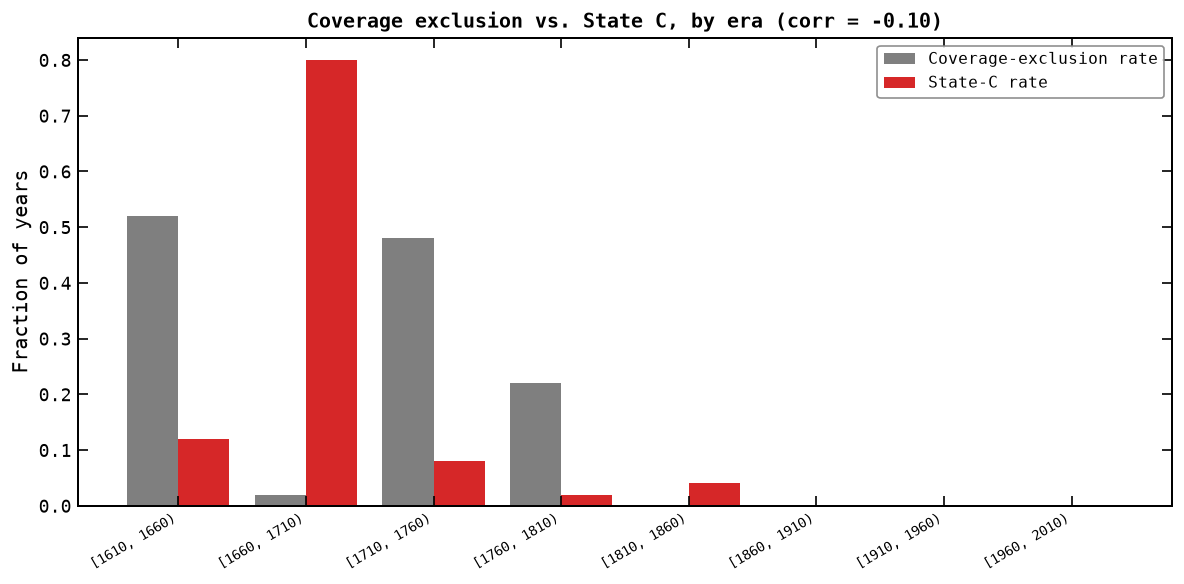

In [40]:
_era_edges = list(range(1610, 2011, 50))
_era_df = annual_full.copy()
_era_df["era"] = pd.cut(_era_df["YEAR"], bins=_era_edges, right=False)
_era_df["excluded"] = _era_df["valid_days"] < MIN_VALID_DAYS
_era_df["is_state_C"] = _era_df["YEAR"].isin(set(years_C))

_era_stats = _era_df.groupby("era", observed=True).agg(
    n_years=("YEAR", "count"),
    exclusion_rate=("excluded", "mean"),
    state_C_rate=("is_state_C", "mean"),
).reset_index()
_era_stats["era"] = _era_stats["era"].astype(str)
display(_era_stats)

_corr_era = _era_stats["exclusion_rate"].corr(_era_stats["state_C_rate"])
print(f"Correlation (exclusion rate, State-C rate) across {len(_era_stats)} 50-year eras: {_corr_era:+.3f}")

with plt.rc_context(SUPER_MONGO_RC):
    fig, ax = plt.subplots(figsize=(10, 5))
    _x_pos = np.arange(len(_era_stats))
    ax.bar(_x_pos - 0.2, _era_stats["exclusion_rate"], width=0.4,
           color="#7f7f7f", label="Coverage-exclusion rate")
    ax.bar(_x_pos + 0.2, _era_stats["state_C_rate"], width=0.4,
           color="#d62728", label="State-C rate")
    ax.set_xticks(_x_pos)
    ax.set_xticklabels(_era_stats["era"], rotation=30, ha="right", fontsize=8.5)
    ax.set_ylabel("Fraction of years", fontsize=12)
    ax.set_title(f"Coverage exclusion vs. State C, by era (corr = {_corr_era:+.2f})",
                  fontsize=12, fontweight="bold")
    ax.legend(fontsize=9.5, framealpha=0.88, edgecolor="gray")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    plt.tight_layout()
    plt.show()

FIGURES["missingness_diagnostic"] = fig

### Posterior state probabilities (soft decoding)

The Viterbi path above gives a single "hard" state label per year -- the
single most likely *sequence*. It does not, by itself, say how confident the
model is at any given year. The forward-backward algorithm instead gives,
for each year, the posterior probability of being in each state given the
*entire* observed sequence, $P(\text{state}_t \mid \mathbf{x})$. This is
smoothed, not filtered: it uses information from both before and after year
$t$. Below we extract $P(\text{state}=C)$ per year and use it in fig02 and
fig04 to show *how gradual or abrupt* the model's belief in a Grand Minimum
actually is near a state boundary -- most notably around the 1645-1666
onset window discussed in fig04.

In [41]:
_state_probs_3 = best_model_3.predict_proba(X_train_3)
_prob_by_year = pd.DataFrame({
    "YEAR": df_valid3["YEAR"].values,
    "P_A": _state_probs_3[:, state_A_idx3],
    "P_B": _state_probs_3[:, state_B_idx3],
    "P_C": _state_probs_3[:, state_C_idx],
})
posterior_probs = annual_full[["YEAR"]].merge(_prob_by_year, on="YEAR", how="left")

print("Posterior P(state=C) around the 1645-1666 onset window:")
display(posterior_probs[(posterior_probs["YEAR"] >= 1640) & (posterior_probs["YEAR"] <= 1670)]
        [["YEAR", "P_C"]].round(3))

Posterior P(state=C) around the 1645-1666 onset window:


,YEAR,P_C
30,1640,NaN
31,1641,NaN
32,1642,0.000
33,1643,0.000
34,1644,0.000
35,1645,NaN
36,1646,NaN
37,1647,NaN
38,1648,0.979
39,1649,NaN


### Sensitivity of the Grand-Minimum boundary to the classification threshold

The Viterbi decoding above implicitly uses a hard decision rule. Here we
instead classify a year as State~C whenever its posterior probability
$P(\text{state}=C)$ exceeds a threshold $\tau$, and sweep $\tau$ from 0.1 to
0.9, tracking (i) the total number of years assigned to State~C and (ii)
the onset year of the main continuous Maunder-era block. If the boundary is
sensitive to $\tau$, the reported "1666 onset" would be an artefact of the
0.5 default; if it is stable, it is a robust feature of the fitted model.

In [42]:
_thresholds = np.arange(0.1, 0.95, 0.1)
_threshold_rows = []
_anchor_year = 1670  # a year deep within the accepted continuous Maunder episode
for tau in _thresholds:
    _years_tau = sorted(posterior_probs.loc[posterior_probs["P_C"] > tau, "YEAR"].tolist())
    _intervals_tau = get_contiguous_intervals(_years_tau)
    _anchor_block = next((iv for iv in _intervals_tau if iv[0] <= _anchor_year <= iv[1]), None)
    _threshold_rows.append({
        "threshold": round(tau, 2),
        "n_years_state_C": len(_years_tau),
        "n_intervals": len(_intervals_tau),
        "block_containing_1670_onset": _anchor_block[0] if _anchor_block else None,
        "block_containing_1670_end": _anchor_block[1] if _anchor_block else None,
    })

threshold_sensitivity = pd.DataFrame(_threshold_rows)
display(threshold_sensitivity)

_onset_values = threshold_sensitivity["block_containing_1670_onset"].dropna().unique()
_valid_years = set(df_valid3["YEAR"])
for _o in _onset_values:
    _prev = max(y for y in _valid_years if y < _o)
    print(f"Block onset = {int(_o)}; previous valid year = {_prev} "
          f"({int(_o) - _prev - 1} year(s) with no data in between) -> the onset is "
          f"limited by data availability, not by tau.")
print("\nBlock end and number of intervals, by tau:")
display(threshold_sensitivity[["threshold", "n_years_state_C", "n_intervals", "block_containing_1670_end"]])

,threshold,n_years_state_C,n_intervals,block_containing_1670_onset,block_containing_1670_end
0,0.1,55,11,1666,1675
1,0.2,54,10,1666,1675
2,0.3,53,9,1666,1675
3,0.4,53,9,1666,1675
4,0.5,53,9,1666,1675
5,0.6,53,9,1666,1675
6,0.7,53,9,1666,1675
7,0.8,53,9,1666,1675
8,0.9,53,9,1666,1675


Block onset = 1666; previous valid year = 1664 (1 year(s) with no data in between) -> the onset is limited by data availability, not by tau.

Block end and number of intervals, by tau:


,threshold,n_years_state_C,n_intervals,block_containing_1670_end
0,0.1,55,11,1675
1,0.2,54,10,1675
2,0.3,53,9,1675
3,0.4,53,9,1675
4,0.5,53,9,1675
5,0.6,53,9,1675
6,0.7,53,9,1675
7,0.8,53,9,1675
8,0.9,53,9,1675


### fig08 -- Bootstrap-calibrated likelihood-ratio test: K=3 vs. K=4

The raw BIC comparison above treats $K=3$ and $K=4$ as if the asymptotic
regularity conditions behind the BIC penalty hold exactly; for nested
Markov-switching models this is not guaranteed, particularly when the extra
state is only weakly identified. Following the approach of
\citet{Mews2025}, we instead calibrate a likelihood-ratio test (LRT)
statistic by parametric bootstrap: we simulate synthetic sequences of the
same length from the fitted $K=3$ model (the null hypothesis), refit both
$K=3$ and $K=4$ to each simulated sequence, and build an empirical null
distribution of $\mathrm{LRT} = 2(\log\hat{L}_{K=4} - \log\hat{L}_{K=3})$.
Comparing the *observed* LRT (from the real data) against this null
distribution tests whether $K=4$'s likelihood improvement is larger than
what sampling noise alone would produce if the data really came from a
3-state process.

To keep runtime tractable, each bootstrap replicate uses 10 random restarts
per model rather than the full 50 used for the primary analysis; the
*observed* LRT, however, uses the primary analysis's full 50-restart fits.

In [43]:
N_BOOTSTRAP = 499
N_RESTARTS_BOOTSTRAP = 20          # SAME budget for the observed fit and for every bootstrap replicate

_r3 = fit_hmm_with_restarts(X_train_3, 3, n_restarts=N_RESTARTS_BOOTSTRAP)
_r4 = fit_hmm_with_restarts(X_train_3, 4, n_restarts=N_RESTARTS_BOOTSTRAP)
lrt_observed = 2 * (_r4["best_logL"] - _r3["best_logL"])
print(f"Observed LRT ({N_RESTARTS_BOOTSTRAP} restarts on both K=3 and K=4): {lrt_observed:.4f}   "
      f"[with the primary 50-restart fits: "
      f"{2 * (bic_df.loc[bic_df.n_states == 4, 'log_L'].item() - bic_df.loc[bic_df.n_states == 3, 'log_L'].item()):.4f}]")

_null_model = best_models_3[3]
lrt_bootstrap = np.empty(N_BOOTSTRAP)
t0 = time.time()
for rep in range(N_BOOTSTRAP):
    X_sim, _ = _null_model.sample(n_train, random_state=rep)
    l3 = fit_hmm_with_restarts(X_sim, n_states=3, n_restarts=N_RESTARTS_BOOTSTRAP)["best_logL"]
    l4 = fit_hmm_with_restarts(X_sim, n_states=4, n_restarts=N_RESTARTS_BOOTSTRAP)["best_logL"]
    lrt_bootstrap[rep] = 2 * (l4 - l3)
    if (rep + 1) % 100 == 0:
        print(f"  {rep + 1}/{N_BOOTSTRAP}  ({time.time() - t0:.0f}s)")
elapsed = time.time() - t0
print(f"Bootstrap complete: {N_BOOTSTRAP} replicates x {N_RESTARTS_BOOTSTRAP} restarts "
      f"x 2 models in {elapsed:.1f}s")


Observed LRT (20 restarts on both K=3 and K=4): 78.3764   [with the primary 50-restart fits: 78.3764]


/Users/rafaelferreira/1_Workspace_Ativo/Papers/MM HMM/.venv/lib/python3.12/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


/Users/rafaelferreira/1_Workspace_Ativo/Papers/MM HMM/.venv/lib/python3.12/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


  100/499  (233s)


/Users/rafaelferreira/1_Workspace_Ativo/Papers/MM HMM/.venv/lib/python3.12/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


...

/Users/rafaelferreira/1_Workspace_Ativo/Papers/MM HMM/.venv/lib/python3.12/site-packages/hmmlearn/hmm.py:386: RuntimeWarning: overflow encountered in divide
  self._covars_ = ((covars_prior + c_n) /


  400/499  (941s)


/Users/rafaelferreira/1_Workspace_Ativo/Papers/MM HMM/.venv/lib/python3.12/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


/Users/rafaelferreira/1_Workspace_Ativo/Papers/MM HMM/.venv/lib/python3.12/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


Bootstrap complete: 499 replicates x 20 restarts x 2 models in 1178.1s


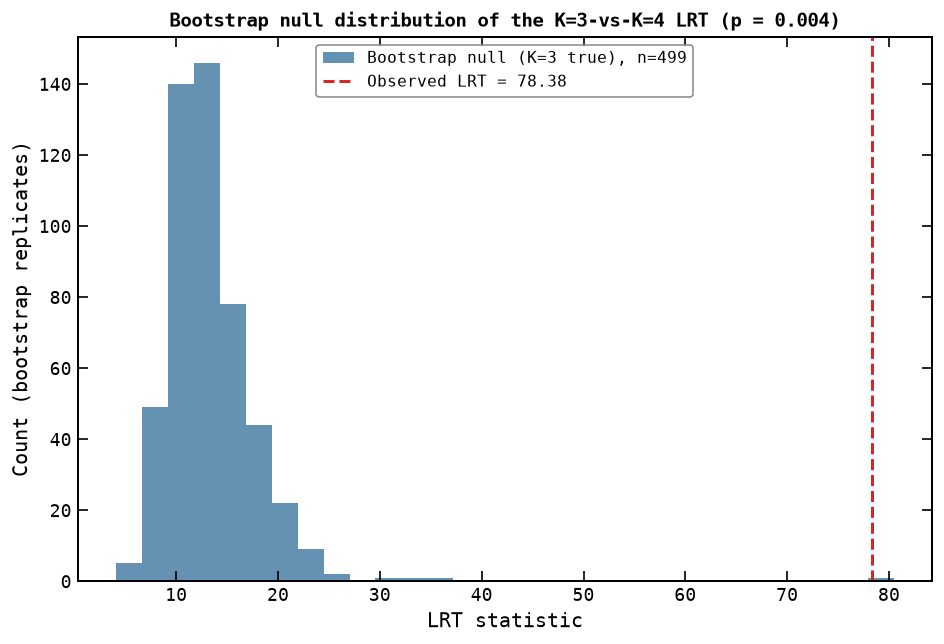

Bootstrap null LRT: mean=13.44, 95th percentile=20.45, max=80.45
Observed LRT: 78.38
p-value = (1 + #{LRT_b >= LRT_obs}) / (B + 1) = 0.0040

The observed likelihood improvement of K=4 over K=3 is larger than essentially all bootstrap replicates simulated under a true K=3 model: K=4's fit is not merely sampling noise around a 3-state truth. This does not contradict the K=3 selection, which rests on physical interpretability and EM stability rather than on K=4 being statistically indistinguishable from noise -- but it means the override should be described as a deliberate preference for interpretability over the (real) additional likelihood, not as evidence that the 4th state is spurious.


In [44]:
_n_ge = int(np.sum(lrt_bootstrap >= lrt_observed))
p_value = (1 + _n_ge) / (N_BOOTSTRAP + 1)
p_label = f"p = {p_value:.3f}" if _n_ge > 0 else f"p < {1 / (N_BOOTSTRAP + 1):.3f}"

with plt.rc_context(SUPER_MONGO_RC):
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.hist(lrt_bootstrap, bins=30, color="#4a7fa5", alpha=0.85,
             label=f"Bootstrap null (K=3 true), n={N_BOOTSTRAP}")
    ax.axvline(lrt_observed, color="#d62728", linewidth=1.8, linestyle="--",
                label=f"Observed LRT = {lrt_observed:.2f}")
    ax.set_xlabel("LRT statistic", fontsize=12)
    ax.set_ylabel("Count (bootstrap replicates)", fontsize=12)
    ax.set_title(f"Bootstrap null distribution of the K=3-vs-K=4 LRT ({p_label})", fontsize=11.5, fontweight="bold")
    ax.legend(fontsize=9.5, framealpha=0.88, edgecolor="gray")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    plt.tight_layout()
    plt.show()

FIGURES["fig08"] = fig

print(f"Bootstrap null LRT: mean={lrt_bootstrap.mean():.2f}, "
      f"95th percentile={np.percentile(lrt_bootstrap, 95):.2f}, "
      f"max={lrt_bootstrap.max():.2f}")
print(f"Observed LRT: {lrt_observed:.2f}")
print(f"p-value = (1 + #{{LRT_b >= LRT_obs}}) / (B + 1) = {p_value:.4f}")
if p_value < 0.05:
    print("\nThe observed likelihood improvement of K=4 over K=3 is larger than "
          "essentially all bootstrap replicates simulated under a true K=3 model: "
          "K=4's fit is not merely sampling noise around a 3-state truth. This does "
          "not contradict the K=3 selection, which rests on physical interpretability "
          "and EM stability rather than on K=4 being statistically indistinguishable "
          "from noise -- but it means the override should be described as a deliberate "
          "preference for interpretability over the (real) additional likelihood, not "
          "as evidence that the 4th state is spurious.")
else:
    print("\nThe observed likelihood improvement of K=4 over K=3 is within the range "
          "produced by sampling noise alone under a true K=3 model, reinforcing that "
          "the raw BIC preference for K=4 does not reflect a robustly identified "
          "additional regime.")


### fig09 -- Posterior predictive check on episode structure

To assess whether the fitted model's own dynamics are consistent with the
observed Grand-Minimum episode structure, we simulate many synthetic state
sequences from the fitted transition matrix (same length as the real
training sequence), map each simulated position back to its calendar year
exactly as the observed sequence is (so coverage gaps do not artificially
inflate contiguous runs), and compare several statistics -- years and
number of contiguous blocks in States C and B, and the longest run in each
-- between the observed sequence and the simulated distribution (inspired
by \citet{Mews2025}'s use of simulated sample paths). This is a
self-consistency check of the fitted model, not independent evidence: the
simulated data are generated by the same model being tested, so close
agreement is expected by construction and does not validate the model
against external information.


,observed,sim_median,sim_2.5%,sim_97.5%,quantile_obs
n_years_C,53,49.5,9.000,116.000,0.570
n_blocks_C,9,7.0,2.000,17.000,0.696
longest_C,18,18.0,5.000,46.000,0.508
n_years_B,147,150.0,106.475,191.525,0.458
n_blocks_B,39,37.0,27.475,47.000,0.644
longest_B,15,17.0,10.000,30.000,0.384


Observed longest contiguous State-C run: 18 years
Simulated (n=500) longest-run distribution: mean=20.3, median=18.0, 95th pct=41.0, max=80
The observed run length falls at the 50.8th percentile of the simulated distribution.


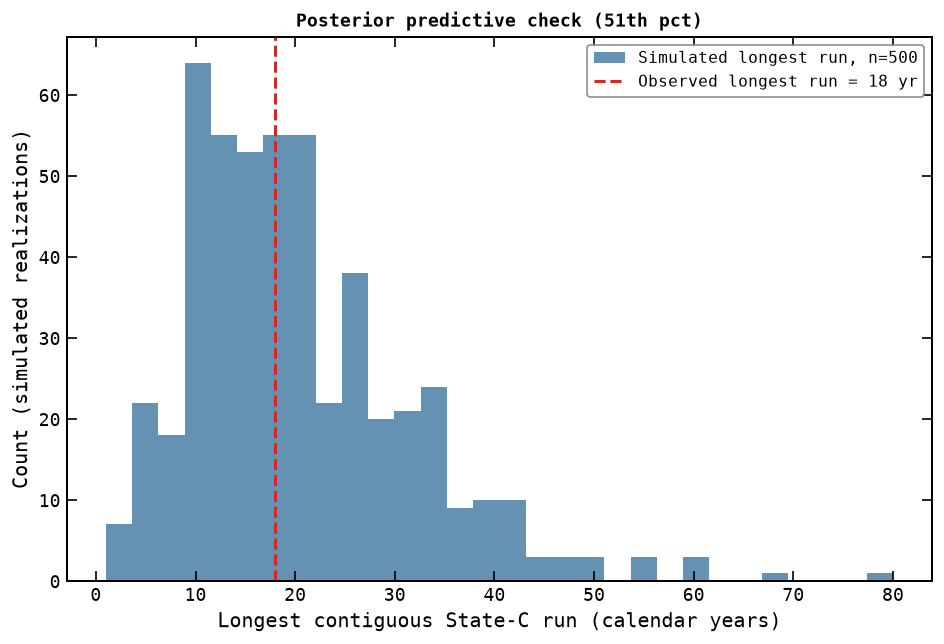

In [45]:
M_SIM = 500
_years_valid = df_valid3["YEAR"].values


def _stats_from_labels(lab):
    out = {}
    for s in ("C", "B"):
        ivs = get_contiguous_intervals(_years_valid[lab == s].tolist())  # contiguity in CALENDAR YEARS
        out[f"n_years_{s}"] = int((lab == s).sum())
        out[f"n_blocks_{s}"] = len(ivs)
        out[f"longest_{s}"] = max((b - a + 1 for a, b in ivs), default=0)
    return out


_obs = _stats_from_labels(state_label_seq)
_sim = pd.DataFrame([
    _stats_from_labels(np.array([idx_to_label[s] for s in best_model_3.sample(n_train, random_state=2000 + i)[1]]))
    for i in range(M_SIM)
])
ppc = pd.DataFrame({
    "observed": pd.Series(_obs),
    "sim_median": _sim.median(),
    "sim_2.5%": _sim.quantile(0.025),
    "sim_97.5%": _sim.quantile(0.975),
    "quantile_obs": pd.Series({k: float((_sim[k] <= _obs[k]).mean()) for k in _obs}),
})
display(ppc.round(3))

_observed_max_run = _obs["longest_C"]
_sim_max_runs = _sim["longest_C"].values
_percentile_rank = float((_sim_max_runs <= _observed_max_run).mean() * 100)

print(f"Observed longest contiguous State-C run: {_observed_max_run} years")
print(f"Simulated (n={M_SIM}) longest-run distribution: mean={_sim_max_runs.mean():.1f}, "
      f"median={np.median(_sim_max_runs):.1f}, 95th pct={np.percentile(_sim_max_runs, 95):.1f}, "
      f"max={_sim_max_runs.max()}")
print(f"The observed run length falls at the {_percentile_rank:.1f}th percentile "
      f"of the simulated distribution.")

with plt.rc_context(SUPER_MONGO_RC):
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.hist(_sim_max_runs, bins=30, color="#4a7fa5", alpha=0.85,
             label=f"Simulated longest run, n={M_SIM}")
    ax.axvline(_observed_max_run, color="#d62728", linewidth=1.8, linestyle="--",
                label=f"Observed longest run = {_observed_max_run} yr")
    ax.set_xlabel("Longest contiguous State-C run (calendar years)", fontsize=12)
    ax.set_ylabel("Count (simulated realizations)", fontsize=12)
    ax.set_title(f"Posterior predictive check ({_percentile_rank:.0f}th pct)", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9.5, framealpha=0.88, edgecolor="gray")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    plt.tight_layout()
    plt.show()

FIGURES["fig09"] = fig


## Section 5 — Manuscript figures (fig01 – fig04)

Each figure below is built in its own **data cell** followed by its own
**plot cell**, deliberately kept independent of the other figures. This is
intentional: figures may still be revised individually (added, removed, or
restyled) as the manuscript goes through review, without needing to rerun
unrelated cells or recompute inputs shared by chance. `shade_intervals` and
the state color/label dictionaries are defined once here and reused by
fig02 and fig04.

In [46]:
def shade_intervals(ax, intervals, color, alpha, label=None, edge_color=None):
    '''Draw axvspan shading for each (start, end) interval on `ax`.'''
    for i, (y1, y2) in enumerate(intervals):
        lbl = label if i == 0 else "_nolegend_"
        ax.axvspan(y1 - 0.5, y2 + 0.5, color=color, alpha=alpha, linewidth=0, zorder=1, label=lbl)
        if edge_color:
            ax.axvline(y1 - 0.5, color=edge_color, linewidth=0.7, alpha=0.6, zorder=2)
            ax.axvline(y2 + 0.5, color=edge_color, linewidth=0.7, alpha=0.6, zorder=2)

STATE_COLORS = {"C": "#d62728", "B": "#ff7f0e", "A": "#1f77b4"}
STATE_ALPHAS = {"C": 0.55, "B": 0.40, "A": 0.25}
STATE_LABELS = {
    "C": "State C -- Grand Minimum",
    "B": "State B -- Reduced Activity",
    "A": "State A -- Normal Activity",
}

In [47]:
def shade_gaps(ax, gap_intervals, xlim=None, label="No data (coverage gap)"):
    '''Lightly hatch calendar-year spans excluded by the coverage filter.

    Without this, a line plot simply breaks at each NaN year; with 23 short
    gaps concentrated before 1793 (see Section 1), the result reads as
    "broken/corrupted" rather than "no data here". Drawn at zorder=0 so it
    sits behind all data lines.
    '''
    first = True
    for y1, y2 in gap_intervals:
        if xlim is not None and (y2 < xlim[0] or y1 > xlim[1]):
            continue
        ax.axvspan(y1 - 0.5, y2 + 0.5, facecolor="0.88", edgecolor="0.6",
                   hatch="///", linewidth=0, alpha=0.6, zorder=0,
                   label=label if first else "_nolegend_")
        first = False


GAP_INTERVALS = get_contiguous_intervals(
    annual_full.loc[annual_full["mean_groups"].isna(), "YEAR"].tolist()
)
print(f"{len(GAP_INTERVALS)} coverage-gap intervals excluded from training "
      f"(shaded in fig01/fig02/fig04 below): {GAP_INTERVALS}")

23 coverage-gap intervals excluded from training (shaded in fig01/fig02/fig04 below): [(1610, 1610), (1614, 1615), (1617, 1617), (1619, 1619), (1622, 1623), (1628, 1628), (1630, 1630), (1633, 1633), (1635, 1641), (1645, 1647), (1649, 1651), (1655, 1656), (1658, 1658), (1665, 1665), (1723, 1724), (1727, 1732), (1734, 1739), (1741, 1748), (1753, 1753), (1759, 1759), (1779, 1780), (1782, 1785), (1789, 1793)]


### fig01 — Dataset overview (no HMM results)

In [48]:
fig01_years = annual_full["YEAR"].values
fig01_mg = annual_full["mean_groups"].values
fig01_af = annual_full["active_fraction"].values
fig01_vd = annual_full["valid_days"].values.astype(float)
fig01_vd[fig01_vd == 0] = np.nan

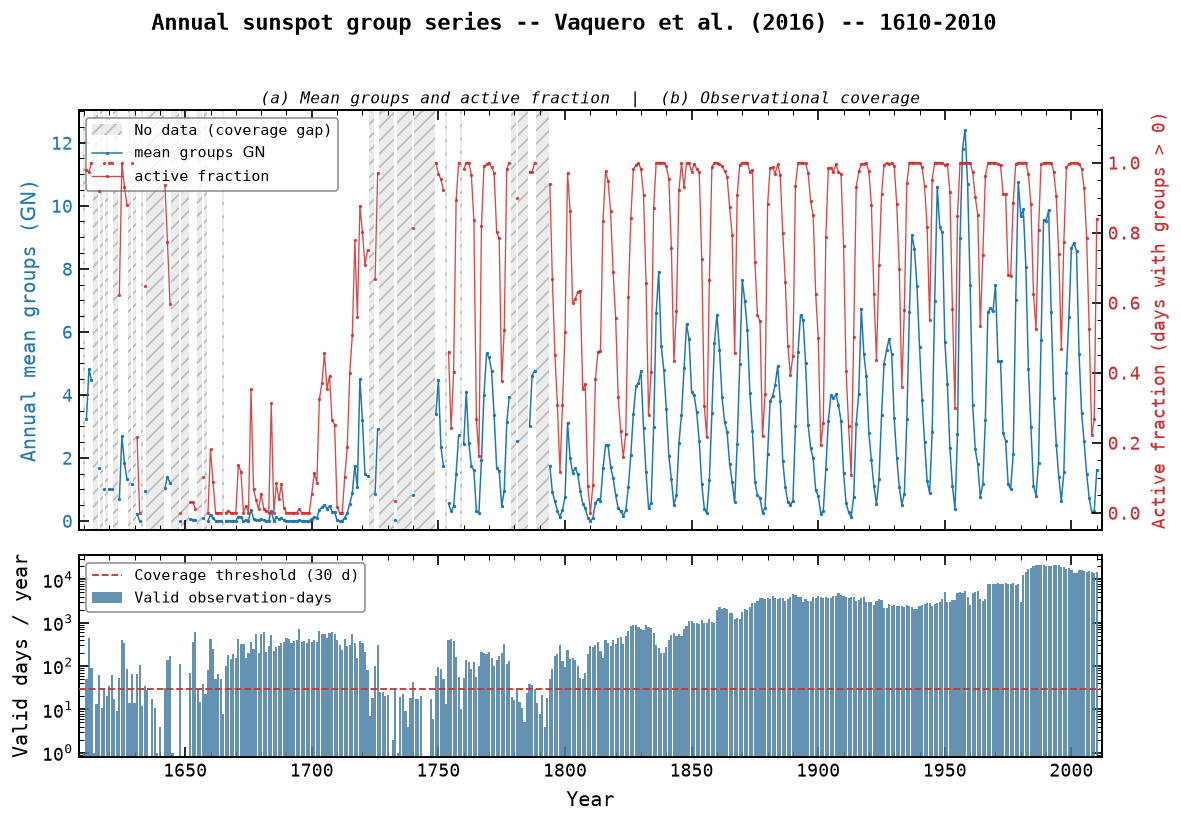

In [49]:
with plt.rc_context(SUPER_MONGO_RC):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [2.5, 1.2], "hspace": 0.08})

    shade_gaps(ax1, GAP_INTERVALS, xlim=(1608, 2012))

    color_mg, color_af = "#1f77b4", "#d62728"
    ax1.plot(fig01_years, fig01_mg, color=color_mg, linewidth=0.9,
              marker="o", markersize=2.0, markeredgewidth=0,
              label=r"mean groups $\mathrm{GN}$", zorder=3)
    ax1.set_ylabel(r"Annual mean groups ($\mathrm{GN}$)", fontsize=12, color=color_mg, labelpad=6)
    ax1.tick_params(axis="y", labelcolor=color_mg)
    ax1.set_ylim(bottom=-0.3)

    ax1r = ax1.twinx()
    ax1r.plot(fig01_years, fig01_af, color=color_af, linewidth=0.8, alpha=0.85,
               marker="o", markersize=2.0, markeredgewidth=0,
               label="active fraction", zorder=2)
    ax1r.set_ylabel("Active fraction (days with groups > 0)", fontsize=11, color=color_af, labelpad=6)
    ax1r.tick_params(axis="y", labelcolor=color_af)
    ax1r.set_ylim(-0.05, 1.15)
    ax1r.tick_params(which="both", direction="in")

    lines1, labs1 = ax1.get_legend_handles_labels()
    lines2, labs2 = ax1r.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labs1 + labs2, loc="upper left", fontsize=9,
               framealpha=0.85, edgecolor="gray")
    ax1.xaxis.set_minor_locator(MultipleLocator(10))
    ax1.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax1.tick_params(which="both", direction="in", top=True, right=False)
    ax1r.yaxis.set_minor_locator(AutoMinorLocator(4))

    ax2.bar(fig01_years, fig01_vd, width=0.85, color="#4a7fa5", alpha=0.85, zorder=2,
            label="Valid observation-days")
    ax2.axhline(30, color="#c0392b", linewidth=1.1, linestyle="--", zorder=3,
                label="Coverage threshold (30 d)")
    ax2.set_yscale("log")
    ax2.set_ylim(bottom=0.8)
    ax2.set_ylabel("Valid days / year", fontsize=12, labelpad=6)
    ax2.set_xlabel("Year", fontsize=12, labelpad=6)
    ax2.legend(loc="upper left", fontsize=9, framealpha=0.85, edgecolor="gray")
    ax2.xaxis.set_minor_locator(MultipleLocator(10))
    ax2.tick_params(which="both", direction="in", top=True, right=True)

    ax1.set_xlim(1608, 2012)
    ax1.xaxis.set_major_locator(MultipleLocator(50))
    ax2.xaxis.set_major_locator(MultipleLocator(50))

    fig.suptitle("Annual sunspot group series -- Vaquero et al. (2016) -- 1610-2010",
                  fontsize=13, fontweight="bold", y=0.997)
    ax1.set_title("(a) Mean groups and active fraction  |  (b) Observational coverage",
                   fontsize=9.5, style="italic", pad=4)
    plt.show()

FIGURES["fig01"] = fig

### fig02 — Central figure: 3-state series with state shading

In [50]:
fig02_years = annual_full["YEAR"].values
fig02_mg = annual_full["mean_groups"].values
fig02_intervals_B = list(intervals_B)
fig02_intervals_C = list(intervals_C)
fig02_P_C = posterior_probs["P_C"].values

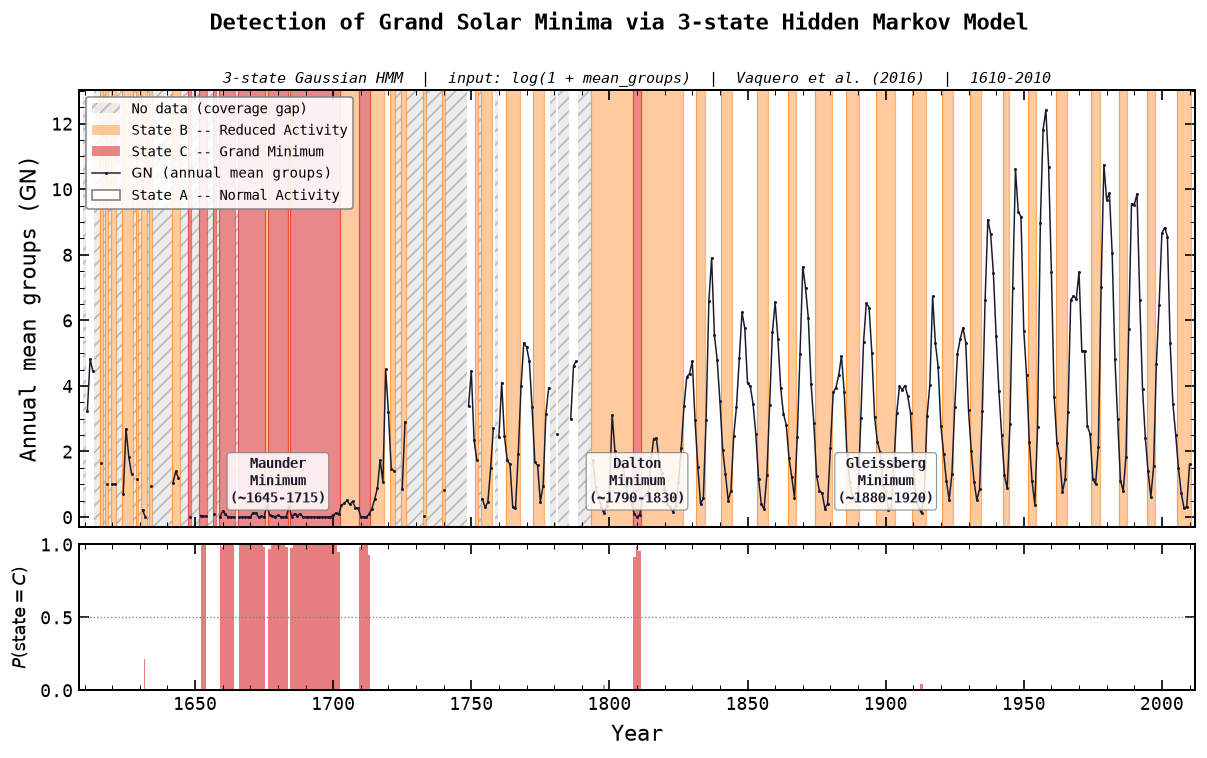

In [51]:
with plt.rc_context(SUPER_MONGO_RC):
    fig, (ax, ax_prob) = plt.subplots(
        2, 1, figsize=(12, 6.5), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.06},
    )

    shade_gaps(ax, GAP_INTERVALS, xlim=(1608, 2012))
    shade_intervals(ax, fig02_intervals_B, STATE_COLORS["B"], STATE_ALPHAS["B"],
                     label=STATE_LABELS["B"], edge_color=STATE_COLORS["B"])
    shade_intervals(ax, fig02_intervals_C, STATE_COLORS["C"], STATE_ALPHAS["C"],
                     label=STATE_LABELS["C"], edge_color=STATE_COLORS["C"])

    ax.plot(fig02_years, fig02_mg, color="#1a1a2e", linewidth=0.9,
             marker="o", markersize=1.8, markeredgewidth=0, zorder=4,
             label=r"$\mathrm{GN}$ (annual mean groups)")

    annot_params = dict(fontsize=8.5, fontweight="bold", ha="center", va="bottom",
                         zorder=6, color="#1a1a2e",
                         bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                                   edgecolor="gray", alpha=0.85, linewidth=0.7))
    ax.text(1680, 0.3, "Maunder\nMinimum\n(~1645-1715)", **annot_params)
    ax.text(1810, 0.3, "Dalton\nMinimum\n(~1790-1830)", **annot_params)
    ax.text(1900, 0.3, "Gleissberg\nMinimum\n(~1880-1920)", **annot_params)

    ax.set_ylim(bottom=-0.3)
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.set_ylabel(r"Annual mean groups ($\mathrm{GN}$)", fontsize=13, labelpad=6)

    patch_A = mpatches.Patch(facecolor="white", edgecolor="gray", label=STATE_LABELS["A"])
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + [patch_A], labels + [STATE_LABELS["A"]],
               loc="upper left", fontsize=8.5, framealpha=0.88, edgecolor="gray")

    ax_prob.fill_between(fig02_years, fig02_P_C, color=STATE_COLORS["C"], alpha=0.6,
                          linewidth=0, step="mid")
    ax_prob.axhline(0.5, color="gray", linewidth=0.8, linestyle=":")
    ax_prob.set_ylim(0, 1)
    ax_prob.set_ylabel(r"$P(\mathrm{state}{=}C)$", fontsize=10.5, labelpad=6)
    ax_prob.set_xlabel("Year", fontsize=13, labelpad=6)
    ax_prob.xaxis.set_major_locator(MultipleLocator(50))
    ax_prob.xaxis.set_minor_locator(MultipleLocator(10))
    ax_prob.tick_params(which="both", direction="in", top=True, right=True)

    ax.set_xlim(1608, 2012)
    ax_prob.set_xlim(1608, 2012)

    fig.suptitle("Detection of Grand Solar Minima via 3-state Hidden Markov Model",
                  fontsize=13, fontweight="bold")
    ax.set_title("3-state Gaussian HMM  |  input: log(1 + mean_groups)  |  "
                  "Vaquero et al. (2016)  |  1610-2010",
                   fontsize=9, style="italic", pad=4)
    plt.show()

FIGURES["fig02"] = fig

### fig03 — Transition matrix and Shannon entropy per state

In [52]:
fig03_T = T3  # already reordered A, B, C
fig03_H_vals = [H_A, H_B, H_C]
fig03_H_names = ["A (Normal)", "B (Reduced)", "C (Grand Min.)"]
fig03_H_colors = [STATE_COLORS["A"], STATE_COLORS["B"], STATE_COLORS["C"]]

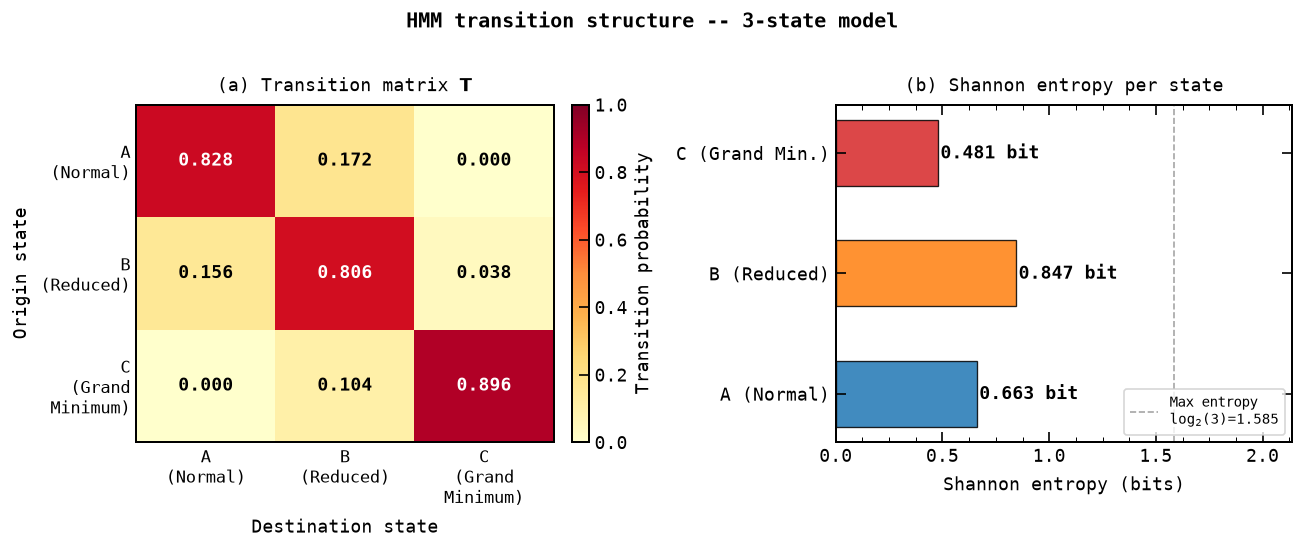

In [53]:
with plt.rc_context(SUPER_MONGO_RC):
    state_names = ["A\n(Normal)", "B\n(Reduced)", "C\n(Grand\nMinimum)"]
    fig, (ax_T, ax_H) = plt.subplots(1, 2, figsize=(11, 4.5))

    im = ax_T.imshow(fig03_T, cmap=plt.cm.YlOrRd, vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax_T, fraction=0.046, pad=0.04, label="Transition probability")
    for i in range(3):
        for j in range(3):
            val = fig03_T[i, j]
            ax_T.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=11,
                       fontweight="bold", color="white" if val > 0.6 else "black")
    ax_T.set_xticks([0, 1, 2]); ax_T.set_yticks([0, 1, 2])
    ax_T.set_xticklabels(state_names, fontsize=10)
    ax_T.set_yticklabels(state_names, fontsize=10)
    ax_T.set_xlabel("Destination state", fontsize=11, labelpad=6)
    ax_T.set_ylabel("Origin state", fontsize=11, labelpad=6)
    ax_T.set_title("(a) Transition matrix $\\mathbf{T}$", fontsize=11, pad=8)
    ax_T.tick_params(which="both", length=0)

    y_pos = np.arange(3)
    bars = ax_H.barh(y_pos, fig03_H_vals, color=fig03_H_colors, alpha=0.85,
                       height=0.55, edgecolor="black", linewidth=0.8)
    for val, bar in zip(fig03_H_vals, bars):
        ax_H.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f} bit",
                   va="center", fontsize=10.5, fontweight="bold")
    ax_H.set_yticks(y_pos); ax_H.set_yticklabels(fig03_H_names, fontsize=10.5)
    ax_H.set_xlabel("Shannon entropy (bits)", fontsize=11, labelpad=6)
    ax_H.set_title("(b) Shannon entropy per state", fontsize=11, pad=8)

    H_max = np.log2(3)
    ax_H.axvline(H_max, color="gray", linewidth=1.0, linestyle="--", alpha=0.7,
                  label=f"Max entropy\nlog$_2$(3)={H_max:.3f}")
    ax_H.legend(fontsize=8.5, loc="lower right")
    ax_H.set_xlim(0, H_max * 1.35)
    ax_H.tick_params(which="both", direction="in", top=True, right=True)
    ax_H.xaxis.set_minor_locator(AutoMinorLocator(4))

    fig.suptitle("HMM transition structure -- 3-state model", fontsize=12,
                  fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

FIGURES["fig03"] = fig

### fig04 — Zoom on the Maunder Minimum (1608–1732)

In [54]:
_mask_zoom = (annual_full["YEAR"] >= 1608) & (annual_full["YEAR"] <= 1732)
fig04_years_z = annual_full.loc[_mask_zoom, "YEAR"].values
fig04_mg_z = annual_full.loc[_mask_zoom, "mean_groups"].values
fig04_vd_z = annual_full.loc[_mask_zoom, "valid_days"].values.astype(float)
fig04_vd_z[fig04_vd_z == 0] = np.nan
fig04_intervals_C_zoom = get_contiguous_intervals([y for y in years_C if 1608 <= y <= 1732])
fig04_P_C_z = posterior_probs.loc[_mask_zoom, "P_C"].values

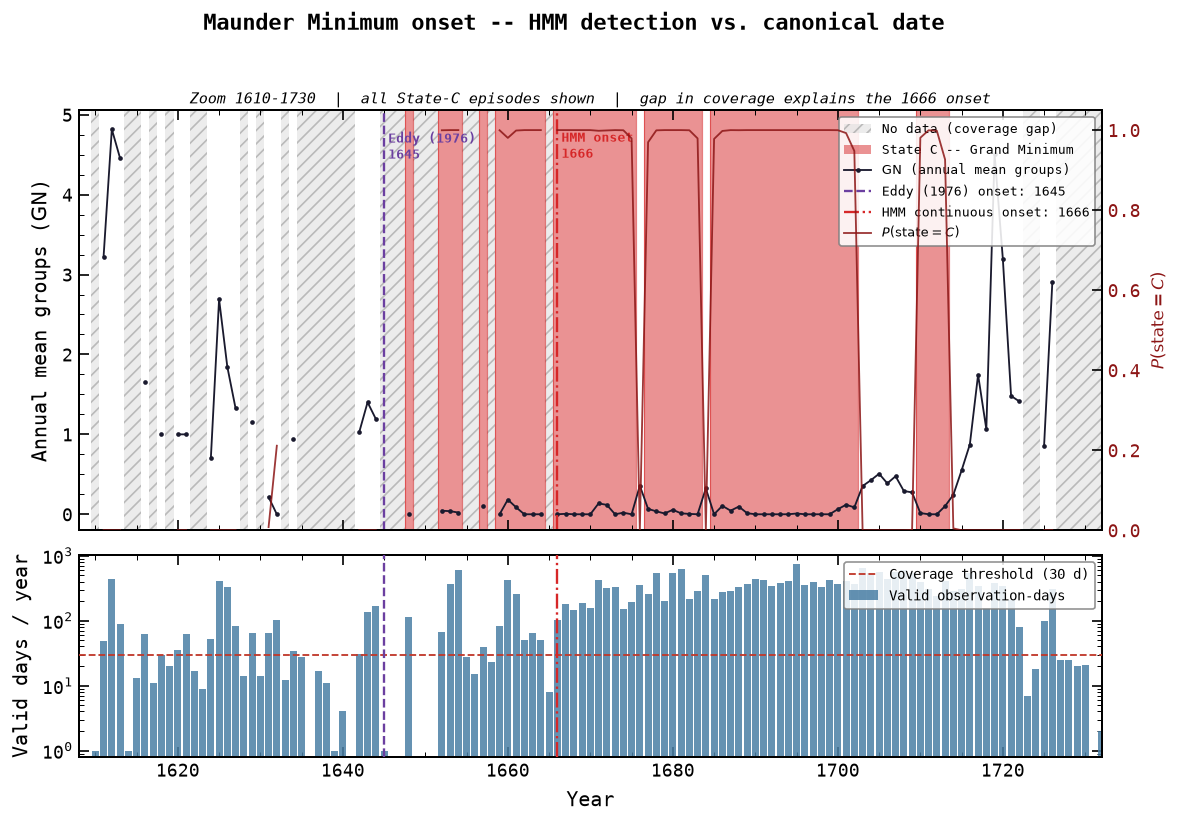

In [55]:
with plt.rc_context(SUPER_MONGO_RC):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [2.5, 1.2], "hspace": 0.08})

    shade_gaps(ax1, GAP_INTERVALS, xlim=(1608, 1732))
    shade_intervals(ax1, fig04_intervals_C_zoom, STATE_COLORS["C"], 0.50,
                     label=STATE_LABELS["C"], edge_color=STATE_COLORS["C"])
    ax1.plot(fig04_years_z, fig04_mg_z, color="#1a1a2e", linewidth=1.1,
              marker="o", markersize=2.8, markeredgewidth=0, zorder=4,
              label=r"$\mathrm{GN}$ (annual mean groups)")

    ax1.axvline(1645, color="#6b3fa0", linewidth=1.4, linestyle="--", zorder=5,
                 label="Eddy (1976) onset: 1645")
    ax1.axvline(1666, color="#d62728", linewidth=1.4, linestyle="-.", zorder=5,
                 label="HMM continuous onset: 1666")

    ax1.set_ylabel(r"Annual mean groups ($\mathrm{GN}$)", fontsize=12, labelpad=6)
    ymax = np.nanmax(fig04_mg_z) * 1.05
    ax1.set_ylim(-0.2, ymax)
    ax1.text(1645.5, ymax * 0.95, "Eddy (1976)\n1645", color="#6b3fa0", fontsize=8,
              va="top", fontweight="bold")
    ax1.text(1666.5, ymax * 0.95, "HMM onset\n1666", color="#d62728", fontsize=8,
              va="top", fontweight="bold")

    ax1r = ax1.twinx()
    ax1r.plot(fig04_years_z, fig04_P_C_z, color="#8c1515", linewidth=1.1,
               linestyle="-", alpha=0.85, zorder=3, label=r"$P(\mathrm{state}{=}C)$")
    ax1r.set_ylim(0, 1.05)
    ax1r.set_ylabel(r"$P(\mathrm{state}{=}C)$", fontsize=10, color="#8c1515", labelpad=6)
    ax1r.tick_params(axis="y", labelcolor="#8c1515", direction="in")

    _lines1, _labs1 = ax1.get_legend_handles_labels()
    _lines2, _labs2 = ax1r.get_legend_handles_labels()
    ax1.legend(_lines1 + _lines2, _labs1 + _labs2, loc="upper right", fontsize=8,
               framealpha=0.88, edgecolor="gray")
    ax1.xaxis.set_minor_locator(MultipleLocator(5))
    ax1.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax1.tick_params(which="both", direction="in", top=True, right=False)

    ax2.bar(fig04_years_z, fig04_vd_z, width=0.85, color="#4a7fa5", alpha=0.85,
            zorder=2, label="Valid observation-days")
    ax2.axhline(30, color="#c0392b", linewidth=1.1, linestyle="--", zorder=3,
                label="Coverage threshold (30 d)")
    ax2.axvline(1645, color="#6b3fa0", linewidth=1.4, linestyle="--", zorder=4)
    ax2.axvline(1666, color="#d62728", linewidth=1.4, linestyle="-.", zorder=4)
    ax2.set_yscale("log")
    ax2.set_ylim(bottom=0.8)
    ax2.set_ylabel("Valid days / year", fontsize=12, labelpad=6)
    ax2.set_xlabel("Year", fontsize=12, labelpad=6)
    ax2.legend(loc="upper right", fontsize=8.5, framealpha=0.85, edgecolor="gray")
    ax2.xaxis.set_minor_locator(MultipleLocator(5))
    ax2.tick_params(which="both", direction="in", top=True, right=True)

    ax1.set_xlim(1608, 1732); ax2.set_xlim(1608, 1732)
    ax1.xaxis.set_major_locator(MultipleLocator(20))
    ax2.xaxis.set_major_locator(MultipleLocator(20))

    fig.suptitle("Maunder Minimum onset -- HMM detection vs. canonical date",
                  fontsize=13, fontweight="bold", y=0.997)
    ax1.set_title("Zoom 1610-1730  |  all State-C episodes shown  |  "
                   "gap in coverage explains the 1666 onset",
                   fontsize=9, style="italic", pad=4)
    plt.show()

FIGURES["fig04"] = fig

### fig07 — Independent validation: `active_fraction` vs. `mean_groups` by state

`active_fraction` is not used to train the HMM (only `log1p_mean_groups`
is). This scatter shows both variables together, colored by the
Viterbi-decoded state, as a direct visual counterpart to the
mean-and-standard-deviation validation reported above: if the states are
physically meaningful, they should separate cleanly in this space even
though only one of the two axes informed the fit.

In [56]:
fig07_mg = df_valid3["mean_groups"].values
fig07_af = df_valid3["active_fraction"].values
fig07_labels = state_label_seq


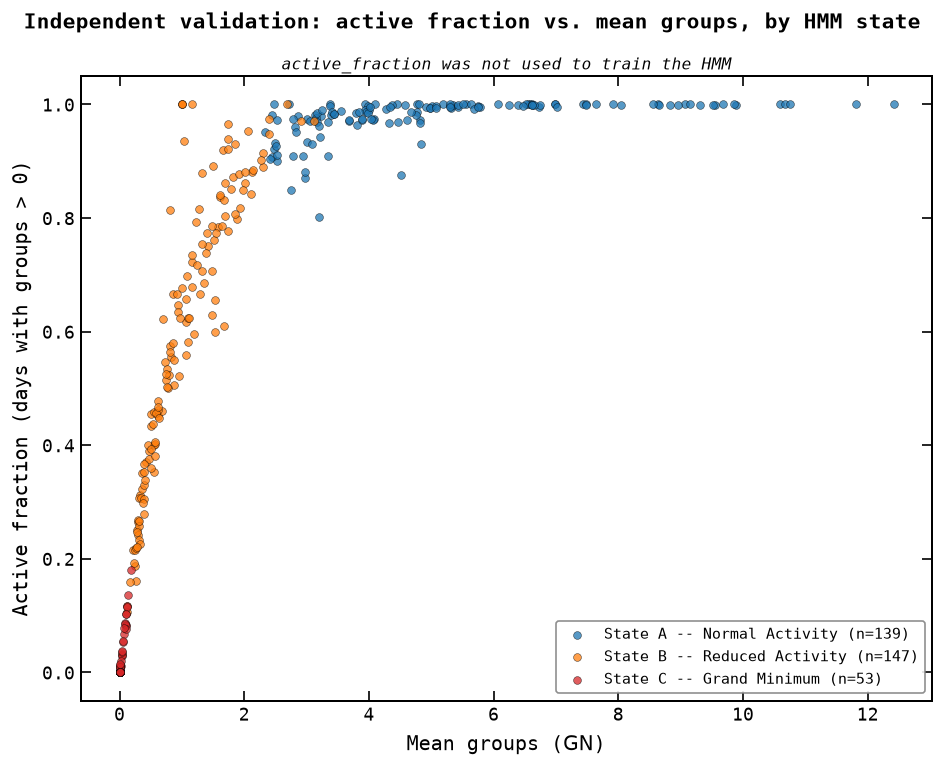

In [57]:
with plt.rc_context(SUPER_MONGO_RC):
    fig, ax = plt.subplots(figsize=(8, 6.5))

    for lbl in ("A", "B", "C"):
        mask = fig07_labels == lbl
        ax.scatter(fig07_mg[mask], fig07_af[mask], s=22, color=STATE_COLORS[lbl],
                   alpha=0.75, edgecolor="black", linewidth=0.3,
                   label=f"{STATE_LABELS[lbl]} (n={mask.sum()})", zorder=3)

    ax.set_xlabel(r"Mean groups ($\mathrm{GN}$)", fontsize=12, labelpad=6)
    ax.set_ylabel("Active fraction (days with groups > 0)", fontsize=12, labelpad=6)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.legend(fontsize=9, framealpha=0.88, edgecolor="gray", loc="lower right")

    fig.suptitle("Independent validation: active fraction vs. mean groups, by HMM state",
                  fontsize=12.5, fontweight="bold")
    ax.set_title("active_fraction was not used to train the HMM", fontsize=9.5,
                  style="italic", pad=4)
    plt.tight_layout()
    plt.show()

FIGURES["fig07"] = fig

## Section 6 — Export

All tables, parameter reports, and figures collected throughout the
notebook are written here under `./outputs/{data,params,figures}/`, using
relative paths only.


In [58]:
for name, df_out in EXPORT_TABLES.items():
    out_path = OUTPUT_DATA_DIR / f"{name}.csv"
    df_out.to_csv(out_path, index=False, float_format="%.6f")
    print(f"Wrote {out_path.relative_to(BASE_DIR)}  ({len(df_out)} rows)")

Wrote outputs/data/annual_series.csv  (401 rows)
Wrote outputs/data/coverage.csv  (401 rows)
Wrote outputs/data/results_q2.csv  (401 rows)
Wrote outputs/data/bic_table.csv  (3 rows)


In [59]:
for name, report_text in PARAM_REPORTS.items():
    out_path = OUTPUT_PARAMS_DIR / f"{name}.txt"
    out_path.write_text(report_text)
    print(f"Wrote {out_path.relative_to(BASE_DIR)}")

Wrote outputs/params/hmm2_params.txt
Wrote outputs/params/hmm3_params.txt


In [60]:
_figure_formats = {"inspection_plot": "png"}  # everything else defaults to pdf
for name, fig in FIGURES.items():
    ext = _figure_formats.get(name, "pdf")
    out_path = OUTPUT_FIGURES_DIR / f"{name}.{ext}"
    try:
        dpi = 150 if ext == "png" else None
        fig.savefig(out_path, format=ext, dpi=dpi, bbox_inches="tight")
        print(f"Wrote {out_path.relative_to(BASE_DIR)}")
    except Exception as e:
        warnings.warn(f"Could not save figure '{name}': {e}")

Wrote outputs/figures/fig05.pdf


Wrote outputs/figures/inspection_plot.png


Wrote outputs/figures/figure_2state.pdf
Wrote outputs/figures/restart_stability.pdf
Wrote outputs/figures/model_selection_summary.pdf


Wrote outputs/figures/fig06.pdf
Wrote outputs/figures/missingness_diagnostic.pdf
Wrote outputs/figures/fig08.pdf
Wrote outputs/figures/fig09.pdf


Wrote outputs/figures/fig01.pdf
Wrote outputs/figures/fig02.pdf


Wrote outputs/figures/fig03.pdf


Wrote outputs/figures/fig04.pdf
Wrote outputs/figures/fig07.pdf


In [61]:
_manifest = []
for sub in ("data", "params", "figures"):
    for p in sorted((OUTPUT_DIR / sub).glob("*")):
        _manifest.append({"file": str(p.relative_to(OUTPUT_DIR)), "size_KB": round(p.stat().st_size / 1024, 1)})
display(pd.DataFrame(_manifest))

,file,size_KB
0,data/annual_series.csv,12.8
1,data/bic_table.csv,0.1
2,data/coverage.csv,3.6
3,data/results_q2.csv,16.6
4,params/hmm2_params.txt,1.6
5,params/hmm3_params.txt,2.9
6,figures/fig01.pdf,64.4
7,figures/fig02.pdf,63.6
8,figures/fig03.pdf,34.4
9,figures/fig04.pdf,53.4


## Section 7 — Summary of key results

A compact reference table, useful for a quick sanity check without rerunning
the whole notebook.

In [62]:
summary_states = pd.DataFrame([
    {"state": "A (Normal)", "mu_log1p": means_3[state_A_idx3], "sigma_log1p": stds_3[state_A_idx3],
     "mean_groups": mu_A, "active_fraction_mean": active_fraction_stats["A"]["af_mean"],
     "active_fraction_std": active_fraction_stats["A"]["af_std"],
     "duration_yr": dur_A, "shannon_entropy_bits": H_A},
    {"state": "B (Reduced)", "mu_log1p": means_3[state_B_idx3], "sigma_log1p": stds_3[state_B_idx3],
     "mean_groups": mu_B, "active_fraction_mean": active_fraction_stats["B"]["af_mean"],
     "active_fraction_std": active_fraction_stats["B"]["af_std"],
     "duration_yr": dur_B, "shannon_entropy_bits": H_B},
    {"state": "C (Grand Minimum)", "mu_log1p": means_3[state_C_idx], "sigma_log1p": stds_3[state_C_idx],
     "mean_groups": mu_C, "active_fraction_mean": active_fraction_stats["C"]["af_mean"],
     "active_fraction_std": active_fraction_stats["C"]["af_std"],
     "duration_yr": dur_C, "shannon_entropy_bits": H_C},
])
display(summary_states.round(4))

,state,mu_log1p,sigma_log1p,mean_groups,active_fraction_mean,active_fraction_std,duration_yr,shannon_entropy_bits
0,A (Normal),1.7438,0.3646,4.7189,0.9784,0.0347,5.8089,0.6626
1,B (Reduced),0.6778,0.3388,0.9695,0.5899,0.2546,5.1603,0.8468
2,C (Grand Minimum),0.0318,0.0457,0.0323,0.0313,0.0447,9.6454,0.4805


In [63]:
_bic_display = bic_df.copy()
_bic_display["selected"] = _bic_display["n_states"] == SELECTED_N_STATES
display(_bic_display.round(4))

,n_states,log_L,n_params,BIC,best_seed,logL_std,n_nonmonotone,n_not_converged,frac_near_best,n_failed,selected
0,2,-232.4701,7,505.7223,9,64.5779,0,0,0.68,0,False
1,3,-144.2298,14,370.0237,6,51.3578,0,0,0.80,0,True
2,4,-105.0416,23,344.0813,49,54.7222,1,0,0.20,0,False


In [64]:
intervals_C_table = pd.DataFrame(
    [{"start": y1, "end": y2, "duration_yr": y2 - y1 + 1} for y1, y2 in intervals_C]
)
display(intervals_C_table)

,start,end,duration_yr
0,1648,1648,1
1,1652,1654,3
2,1657,1657,1
3,1659,1664,6
4,1666,1675,10
5,1677,1683,7
6,1685,1702,18
7,1710,1713,4
8,1809,1811,3


## Section 8 — Robustness and extensions

The cells below add the sensitivity checks and model variants used to
support the claims in the manuscript's Sections 3.6/4.4 and its discussion
of limitations. They are not required to reproduce the primary results of
Sections 1–7 above, but are provided here for full reproducibility of every
number cited in the manuscript. `hmm_missing.py` (included alongside this
notebook) implements a custom EM for 1-D HMMs with missing observations and
an optional state-dependent AR(1) emission; it is verified below to
reproduce `hmmlearn`'s log-likelihood on complete data before being used
for anything downstream.


### Sanity check: `hmm_missing.py` against `hmmlearn`


In [65]:
from hmm_missing import MissingHMM, fit_restarts, bic, bootstrap_lrt, contiguous_runs

_ml_check = fit_hmm_with_restarts(X_train_3, 3, n_restarts=N_RESTARTS,
                                   hmm_kwargs=dict(covars_prior=1e-6, min_covar=1e-4))
_sanity = fit_restarts(X_train_3.ravel(), K=3, ar=False, n_restarts=N_RESTARTS, seed0=0)
print(f"hmmlearn (near-ML, matched prior) best_logL: {_ml_check['best_logL']:.6f}")
print(f"hmm_missing (pure ML) best_logL:             {_sanity['best_logL']:.6f}")
print(f"difference: {abs(_ml_check['best_logL'] - _sanity['best_logL']):.6f}")
assert abs(_ml_check["best_logL"] - _sanity["best_logL"]) < 0.01, "hmm_missing.py sanity check FAILED"
print("hmm_missing.py reproduces hmmlearn's log-likelihood on complete data -- sanity check passed.")


hmmlearn (near-ML, matched prior) best_logL: -144.108067
hmm_missing (pure ML) best_logL:             -144.108102
difference: 0.000035
hmm_missing.py reproduces hmmlearn's log-likelihood on complete data -- sanity check passed.


### `NB-N1` — Checking factual claims used in the manuscript


In [66]:
_a = annual_full.set_index("YEAR")
print("--- 1640-1670: valid_days and mean_groups ---")
print(_a.loc[1640:1670, ["valid_days", "mean_groups"]].to_string())

print("\n--- Maunder-block interruptions (1676, 1684, 1703-1709) ---")
lab_by_year = dict(zip(df_valid3["YEAR"], df_valid3["hmm_state_label"]))
print({y: lab_by_year.get(y, "NO DATA") for y in [1676, 1684, *range(1703, 1710)]})

print("\n--- 1808-1812: valid_days and mean_groups ---")
print(_a.loc[1808:1812, ["valid_days", "mean_groups"]].to_string())

pos = {y: i for i, y in enumerate(df_valid3["YEAR"])}
print("\n--- Position in the concatenated training index ---")
print({y: pos[y] for y in (1648, 1652, 1664, 1666) if y in pos})

_gaps = get_contiguous_intervals(annual_full.loc[annual_full.mean_groups.isna(), "YEAR"].tolist())
_blocks = get_contiguous_intervals(df_valid3["YEAR"].tolist())
print(f"\ncoverage gaps: {len(_gaps)}  |  training blocks: {len(_blocks)}  |  "
      f"first valid year: {df_valid3.YEAR.min()}  |  last valid year: {df_valid3.YEAR.max()}")


--- 1640-1670: valid_days and mean_groups ---
      valid_days  mean_groups
YEAR                         
1640           4          NaN
1641           0          NaN
1642          31     1.032258
1643         137     1.401460
1644         166     1.192771
1645           1          NaN
1646           0          NaN
1647           0          NaN
1648         113     0.000000
1649           0          NaN
1650           0          NaN
1651           0          NaN
1652          68     0.044118
1653         360     0.038889
1654         603     0.021559
1655          28          NaN
1656          15          NaN
1657          39     0.102564
1658          23          NaN
1659          82     0.000000
1660         425     0.183529
1661         253     0.086957
1662          51     0.000000
1663          65     0.000000
1664          50     0.000000
1665           8          NaN
1666         101     0.000000
1667         181     0.005525
1668         147     0.000000
1669         189     0.0

### `NB-N5` — HMM vs. an i.i.d. Gaussian mixture


In [67]:
from sklearn.mixture import GaussianMixture

_mix_rows = []
for K in (1, 2, 3, 4):
    _gm = GaussianMixture(K, covariance_type="full", n_init=50, random_state=0, reg_covar=1e-6).fit(X_train_3)
    _ll = _gm.score(X_train_3) * n_train
    _k = 3 * K - 1
    _mix_rows.append({"K": K, "logL_mixture": _ll, "k": _k, "BIC_mixture": -2 * _ll + _k * np.log(n_train)})
mix_df = pd.DataFrame(_mix_rows).merge(
    bic_df[["n_states", "log_L", "BIC"]].rename(columns={"n_states": "K", "log_L": "logL_HMM", "BIC": "BIC_HMM"}),
    on="K", how="left")
display(mix_df.round(2))
print("\nBIC_HMM(3) vs. BIC_mixture(3):", bic_df.loc[bic_df.n_states == 3, "BIC"].item(), "vs.",
      mix_df.loc[mix_df.K == 3, "BIC_mixture"].item())


,K,logL_mixture,k,BIC_mixture,logL_HMM,BIC_HMM
0,1,-370.91,2,753.47,NaN,NaN
1,2,-341.76,5,712.64,-232.47,505.72
2,3,-240.40,8,527.41,-144.23,370.02
3,4,-294.63,11,653.35,-105.04,344.08



BIC_HMM(3) vs. BIC_mixture(3): 370.02365720819876 vs. 527.4050377795965


### `NB-N7` (part 2) — Sensitivity to `hmmlearn`'s covariance prior


In [68]:
_r_ml = fit_hmm_with_restarts(X_train_3, 3, n_restarts=N_RESTARTS,
                               hmm_kwargs=dict(covars_prior=1e-6, min_covar=1e-4))
_mm = _r_ml["best_model"]
_oo_ml = np.argsort(_mm.means_.ravel())
_oo_default = np.argsort(best_model_3.means_.ravel())
_partition_ml = np.argsort(_oo_ml)[_mm.decode(X_train_3)[1]]
_partition_default = np.argsort(_oo_default)[best_model_3.decode(X_train_3)[1]]
print("sigma (C,B,A), near-ML  (covars_prior=1e-6):", np.sqrt(_mm.covars_.ravel()[_oo_ml]).round(4))
print("sigma (C,B,A), default (covars_prior=1e-2):", np.sqrt(best_model_3.covars_.ravel()[_oo_default]).round(4))
print("logL near-ML:", round(_r_ml["best_logL"], 4), " | logL default:", round(best_logL_3, 4))
print("same year-by-year partition as primary model:",
      bool(np.array_equal(_partition_ml, _partition_default)))


sigma (C,B,A), near-ML  (covars_prior=1e-6): [0.0434 0.339  0.3642]
sigma (C,B,A), default (covars_prior=1e-2): [0.0457 0.3388 0.3646]
logL near-ML: -144.1081  | logL default: -144.2298
same year-by-year partition as primary model: True


### `NB-N10` — 2-state model in log1p scale (isolates the effect of the log transform)


In [69]:
_r2log = fit_hmm_with_restarts(X_train_3, 2, n_restarts=N_RESTARTS)
_m2log = _r2log["best_model"]
_low2 = np.argmin(_m2log.means_.ravel())
_, _s2log = _m2log.decode(X_train_3)
_y2log = df_valid3.YEAR[_s2log == _low2].tolist()
_y2log_post1750 = [y for y in _y2log if y >= 1750]
print(f"2-state model on log1p(mean_groups): {len(_y2log)} years in the low-activity state")
print(f"  of which {len(_y2log_post1750)} are after 1750: {_y2log_post1750}")
print(f"For comparison: primary 2-state model (raw scale) had {len(years_B_2state)} years; "
      f"primary 3-state model (log scale) has {len(years_C)} years in State C.")


2-state model on log1p(mean_groups): 64 years in the low-activity state
  of which 4 are after 1750: [1808, 1809, 1810, 1811]
For comparison: primary 2-state model (raw scale) had 92 years; primary 3-state model (log scale) has 53 years in State C.


### `NB-N3` — Gap-aware model on the full 401-year grid


In [70]:
x_full = annual_full["log1p_mean_groups"].values.astype(float)
years_full = annual_full["YEAR"].values
LAB = np.array(["C", "B", "A"])

gap_res = {K: fit_restarts(x_full, K, ar=False, n_restarts=N_RESTARTS) for K in (2, 3, 4)}
gap_bic = pd.DataFrame([{"K": K, "logL": r["best_logL"], "k": r["best_model"].n_params(),
                         "BIC": bic(r["best_model"], x_full), "frac_near_best": r["frac_near_best"],
                         "n_not_converged": r["n_not_converged"]} for K, r in gap_res.items()])
display(gap_bic.round(3))
print("Delta-BIC(3->4), full grid:",
      round(gap_bic.loc[gap_bic.K == 3, "BIC"].item() - gap_bic.loc[gap_bic.K == 4, "BIC"].item(), 1))

g3 = gap_res[3]["best_model"]
post_gap = g3.posterior(x_full)
lab_gap = LAB[g3.viterbi(x_full)]
print("mu (log1p) C,B,A:", g3.mu.round(4), " | sigma:", np.sqrt(g3.var).round(4))
print("sojourn C,B,A:", [round(1 / (1 - g3.A[i, i]), 1) for i in range(3)])

blocks_C_gap = contiguous_runs(years_full[lab_gap == "C"].tolist())
print("State-C blocks (full grid):", blocks_C_gap)

tab_gap = pd.DataFrame({"YEAR": years_full, "valid_days": annual_full.valid_days.values,
                        "P_C": post_gap[:, 0], "state": lab_gap})
display(tab_gap[tab_gap.YEAR.between(1640, 1670)].round(3))
print("First year with P(C) > 0.5:", int(tab_gap.loc[tab_gap.P_C > 0.5, "YEAR"].min()))


,K,logL,k,BIC,frac_near_best,n_not_converged
0,2,-230.975,7,502.733,1.0,0
1,3,-142.630,14,366.825,1.0,0
2,4,-103.267,23,340.533,0.2,4


Delta-BIC(3->4), full grid: 26.3
mu (log1p) C,B,A: [0.0317 0.6855 1.7488]  | sigma: [0.0432 0.338  0.3618]
sojourn C,B,A: [np.float64(10.3), np.float64(5.6), np.float64(5.9)]
State-C blocks (full grid): [(1645, 1675), (1677, 1683), (1685, 1702), (1710, 1713), (1809, 1811)]


,YEAR,valid_days,P_C,state
30,1640,4,0.042,B
31,1641,0,0.026,B
32,1642,31,0.000,B
33,1643,137,0.000,B
34,1644,166,0.000,B
35,1645,1,0.275,C
36,1646,0,0.521,C
37,1647,0,0.753,C
38,1648,113,0.982,C
39,1649,0,0.975,C


First year with P(C) > 0.5: 1646


### `NB-N4` — AR(1) emission variant, and LRT bootstrap with an AR(1) null

Runtime: several minutes (the bootstrap fits ~4,000 small HMMs per null).


In [71]:
ar_res = {K: fit_restarts(x_full, K, ar=True, n_restarts=N_RESTARTS) for K in (2, 3, 4)}
ar_bic = pd.DataFrame([{"K": K, "logL": r["best_logL"], "k": r["best_model"].n_params(),
                        "BIC": bic(r["best_model"], x_full),
                        "phi(C,B,A)": np.round(r["best_model"].phi, 3),
                        "n_not_converged": r["n_not_converged"]} for K, r in ar_res.items()])
display(ar_bic)
print("Delta-BIC(3->4), AR(1):",
      round(ar_bic.loc[ar_bic.K == 3, "BIC"].item() - ar_bic.loc[ar_bic.K == 4, "BIC"].item(), 1))
print("(K=4 under AR(1) shows convergence issues --",
      ar_bic.loc[ar_bic.K == 4, "n_not_converged"].item(),
      "/ 50 restarts did not converge -- report this comparison cautiously, see manuscript Sec. 4.4)")

m_ar3 = ar_res[3]["best_model"]
print("AR(1) K=3: mu:", m_ar3.mu.round(3), " phi:", m_ar3.phi.round(3),
      " sojourn:", [round(1 / (1 - m_ar3.A[i, i]), 1) for i in range(3)])

# LRT bootstrap, K=3 vs K=4, i.i.d. null and AR(1) null on the full grid
lrt_iid_full = bootstrap_lrt(x_full, 3, 4, ar=False, B=199, n_restarts=10, n_jobs=-1)
lrt_ar_full = bootstrap_lrt(x_full, 3, 4, ar=True, B=199, n_restarts=10, n_jobs=-1)
for _name, _r in (("i.i.d. null", lrt_iid_full), ("AR(1) null", lrt_ar_full)):
    print(f"{_name}: LRT_obs={_r['lrt_obs']:.2f}  p={_r['p_value']:.3f}  "
          f"(B={_r['B']}, null max={_r['lrt_null'].max():.2f})")


,K,logL,k,BIC,"phi(C,B,A)",n_not_converged
0,2,-76.162724,9,204.759449,"[0.797, 0.612]",0
1,3,-29.979356,17,159.000713,"[0.675, 0.802, 0.611]",2
2,4,-1.050304,27,159.402610,"[0.675, 0.837, 0.566, 0.605]",11


Delta-BIC(3->4), AR(1): -0.4
(K=4 under AR(1) shows convergence issues -- 11 / 50 restarts did not converge -- report this comparison cautiously, see manuscript Sec. 4.4)
AR(1) K=3: mu: [-0.006  0.058  2.232]  phi: [0.675 0.802 0.611]  sojourn: [np.float64(3.3), np.float64(5.5), np.float64(4.2)]


i.i.d. null: LRT_obs=78.73  p=0.005  (B=199, null max=55.65)
AR(1) null: LRT_obs=57.86  p=0.070  (B=199, null max=128.47)


### `NB-N8` — Bootstrap confidence intervals for the transition matrix and sojourn times

Runtime: several minutes (300 replicates x 10 restarts).


In [72]:
B_CI = 300
Ts = np.empty((B_CI, 3, 3))
_t0 = time.time()
for b in range(B_CI):
    Xs, _ = best_model_3.sample(n_train, random_state=5000 + b)
    mb = fit_hmm_with_restarts(Xs, 3, n_restarts=10)["best_model"]
    ob = np.argsort(mb.means_.ravel())[::-1]  # order A, B, C
    Ts[b] = mb.transmat_[np.ix_(ob, ob)]
print(f"Bootstrap ({B_CI} replicates) done in {time.time() - _t0:.0f}s")

lo, hi = np.percentile(Ts, [2.5, 97.5], axis=0)
print("T (A,B,C) point estimate:\n", T3.round(3))
print("95% CI lower:\n", lo.round(3))
print("95% CI upper:\n", hi.round(3))

soj = 1 / (1 - np.stack([Ts[:, i, i] for i in range(3)], axis=1))
print("sojourn A,B,C 95% CI:", np.percentile(soj, [2.5, 97.5], axis=0).round(1).T.tolist())
print("max bootstrap T_AC:", Ts[:, 0, 2].max().round(4), " | max bootstrap T_CA:", Ts[:, 2, 0].max().round(4))


Bootstrap (300 replicates) done in 112s
T (A,B,C) point estimate:
 [[0.828 0.172 0.   ]
 [0.156 0.806 0.038]
 [0.    0.104 0.896]]
95% CI lower:
 [[0.729 0.096 0.   ]
 [0.093 0.67  0.008]
 [0.    0.031 0.704]]
95% CI upper:
 [[0.888 0.267 0.021]
 [0.229 0.865 0.094]
 [0.074 0.271 0.959]]
sojourn A,B,C 95% CI: [[3.7, 8.9], [3.0, 7.4], [3.4, 24.3]]
max bootstrap T_AC: 0.7767  | max bootstrap T_CA: 0.261


### `NB-N8b` — Lag-1 autocorrelation confidence intervals (Fisher-z)


In [73]:
_state_means_log1p = {"A": means_3[state_A_idx3], "B": means_3[state_B_idx3], "C": means_3[state_C_idx]}
_years8b = df_valid3["YEAR"].values
_labels8b = df_valid3["hmm_state_label"].values
_x8b = df_valid3["log1p_mean_groups"].values

for _state in ("A", "B", "C"):
    _py, _py1 = [], []
    for _i in range(len(df_valid3) - 1):
        if _years8b[_i + 1] - _years8b[_i] == 1 and _labels8b[_i] == _state and _labels8b[_i + 1] == _state:
            _py.append(_x8b[_i] - _state_means_log1p[_state])
            _py1.append(_x8b[_i + 1] - _state_means_log1p[_state])
    _n = len(_py)
    _r = np.corrcoef(_py, _py1)[0, 1]
    _z = np.arctanh(_r)
    _se = 1 / np.sqrt(_n - 3)
    _lo, _hi = np.tanh(_z - 1.96 * _se), np.tanh(_z + 1.96 * _se)
    print(f"State {_state}: n_pairs={_n}, r={_r:.3f}, 95% CI=[{_lo:+.2f}, {_hi:+.2f}]")


State A: n_pairs=113, r=0.607, 95% CI=[+0.48, +0.71]
State B: n_pairs=108, r=0.439, 95% CI=[+0.27, +0.58]
State C: n_pairs=44, r=0.224, 95% CI=[-0.08, +0.49]


### Summary

These cells reproduce every number cited in manuscript Sections 3.6, 4.4,
and the robustness paragraphs of Sections 4.1, 4.3, 5.3 and 5.4 — in
particular the two headline findings: (1) the gap-aware full-grid fit
places the onset of continuous State~C at 1645, matching
\citet{Eddy1976}'s canonical date; and (2) the bootstrap likelihood-ratio
test for $K{=}3$ vs.\ $K{=}4$ is no longer significant at the $0.05$ level
once the null model is allowed the AR(1) serial dependence the data
actually show ($p=0.07$, vs.\ $p=0.005$ under an i.i.d.\ null).
